# Analysis Notebook for ACL Paper

This notebook computes statistics and generates tables/figures for the paper.

**Data sources:**
- `Data/narratives/*.csv` - Generated NLEs (9 strategies) - for **efficiency** analysis
- `Data/forsetzung_results/*/geval_*.csv` - G-Eval scores - for **quality** analysis

In [163]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
NARRATIVES_DIR = Path("../Data/narratives")
EVAL_DIR = Path("../Data/forsetzung_results/20250813_135743")

print(f"Narratives dir exists: {NARRATIVES_DIR.exists()}")
print(f"Evaluation dir exists: {EVAL_DIR.exists()}")

Narratives dir exists: True
Evaluation dir exists: True


In [164]:
# Load all narrative files (GENERATION data, not evaluation)
NARRATIVES_DIR = Path("../Data/narratives")

dfs = []
for csv_file in sorted(NARRATIVES_DIR.glob("*.csv")):
    strategy = csv_file.stem  # filename = strategy name
    temp_df = pd.read_csv(csv_file)
    temp_df['Strategy'] = strategy
    dfs.append(temp_df)
    print(f"Loaded {strategy}: {len(temp_df)} rows")

df_all = pd.concat(dfs, ignore_index=True)

# Separate main analysis from temperature sweep
df = df_all[df_all['Strategy'] != 'zero_shot_temp'].copy()
df_temp = df_all[df_all['Strategy'] == 'zero_shot_temp'].copy()

print(f"\n{'='*50}")
print(f"Total rows: {len(df_all):,}")
print(f"Main analysis (excl. temp sweep): {len(df):,}")
print(f"Temperature sweep: {len(df_temp):,}")

print(f"\nFactors in main analysis:")
for col in ['LLM', 'Model', 'XAI', 'Strategy']:
    print(f"  {col}: {df[col].nunique()} levels - {sorted(df[col].unique())}")

Loaded cot_few_shot: 60 rows
Loaded cot_zero_shot: 60 rows
Loaded few_shot: 90 rows
Loaded meta_prompting: 90 rows
Loaded reflexion: 90 rows
Loaded role_based: 90 rows
Loaded self_consistency: 90 rows
Loaded zero_shot: 90 rows
Loaded zero_shot_temp: 1890 rows

Total rows: 2,550
Main analysis (excl. temp sweep): 660
Temperature sweep: 1,890

Factors in main analysis:
  LLM: 3 levels - ['DEEPSEEK', 'GPT', 'L3_LOCAL']
  Model: 4 levels - ['MLP', 'RandomForest', 'SARIMAX', 'XGB']
  XAI: 3 levels - ['lime', 'none', 'shap']
  Strategy: 8 levels - ['cot_few_shot', 'cot_zero_shot', 'few_shot', 'meta_prompting', 'reflexion', 'role_based', 'self_consistency', 'zero_shot']


## 2. Efficiency Table (Table 1 in paper)

Compute Tokens and Time by each experimental factor:
- Strategy (8 prompting strategies)
- XAI (SHAP, LIME, None)
- LLM (GPT-4o, Llama-3, DeepSeek-R1)
- Model (XGBoost, RF, MLP, SARIMAX)

In [165]:
def compute_efficiency_by_factor(data, factor_col):
    """Compute mean ± SD for Tokens and Time by factor level."""
    grouped = data.groupby(factor_col).agg({
        'TokensTotal': ['count', 'mean', 'std'],
        'Duration_s': ['mean', 'std']
    }).round(1)
    
    grouped.columns = ['N', 'Tokens_mean', 'Tokens_std', 'Time_mean', 'Time_std']
    grouped = grouped.reset_index()
    grouped = grouped.rename(columns={factor_col: 'Level'})
    grouped['Factor'] = factor_col
    grouped = grouped[['Factor', 'Level', 'N', 'Tokens_mean', 'Tokens_std', 'Time_mean', 'Time_std']]
    grouped = grouped.sort_values('Tokens_mean')  # Order by tokens ascending
    
    return grouped

# Compute efficiency for each factor (main study)
efficiency_strategy = compute_efficiency_by_factor(df, 'Strategy')
efficiency_xai = compute_efficiency_by_factor(df, 'XAI')
efficiency_llm = compute_efficiency_by_factor(df, 'LLM')
efficiency_model = compute_efficiency_by_factor(df, 'Model')

# Compute efficiency for temperature sweep
efficiency_temp = compute_efficiency_by_factor(df_temp, 'Temperature')
efficiency_temp['Level'] = efficiency_temp['Level'].apply(lambda x: f"{x:.1f}")

# Combine all factors
efficiency_table = pd.concat([
    efficiency_strategy,
    efficiency_xai,
    efficiency_llm,
    efficiency_model,
    efficiency_temp
], ignore_index=True)

# Compute grand mean across ALL data
grand_n = len(df_all)
grand_tokens_mean = df_all['TokensTotal'].mean()
grand_tokens_std = df_all['TokensTotal'].std()
grand_time_mean = df_all['Duration_s'].mean()
grand_time_std = df_all['Duration_s'].std()

print("=" * 80)
print(f"GRAND MEAN: N={grand_n}, Tokens={grand_tokens_mean:.0f}±{grand_tokens_std:.0f}, Time={grand_time_mean:.1f}±{grand_time_std:.1f}")
print("=" * 80)
print("\nEfficiency Table (ordered by Tokens within each factor):")
display(efficiency_table)

GRAND MEAN: N=2550, Tokens=653±1188, Time=35.2±72.0

Efficiency Table (ordered by Tokens within each factor):


,Factor,Level,N,Tokens_mean,Tokens_std,Time_mean,Time_std
0,Strategy,cot_few_shot,60,215.4,39.8,35.2,34.0
1,Strategy,cot_zero_shot,60,279.5,45.7,29.1,27.6
2,Strategy,zero_shot,90,498.6,618.0,22.9,23.7
3,Strategy,few_shot,90,520.4,743.2,29.5,31.8
4,Strategy,meta_prompting,90,525.2,435.0,29.4,32.3
5,Strategy,role_based,90,538.6,605.9,25.1,26.3
6,Strategy,reflexion,90,2184.2,2869.1,132.9,190.2
7,Strategy,self_consistency,90,3717.8,3445.9,219.2,216.8
8,XAI,none,264,919.9,1226.5,62.2,115.5
9,XAI,shap,198,951.8,1181.7,65.8,130.4


In [166]:
def generate_full_latex_efficiency_table(efficiency_df, grand_stats):
    """Generate complete LaTeX efficiency table with grand mean in header."""
    
    # Display name mappings
    level_names = {
        # Strategy
        'zero_shot': 'Zero-shot', 'few_shot': 'Few-shot', 'cot_zero_shot': 'CoT Zero',
        'cot_few_shot': 'CoT Few', 'role_based': 'Role-based', 'meta_prompting': 'Meta-prompt',
        'reflexion': 'Reflexion', 'self_consistency': 'Self-consistency',
        # XAI
        'none': 'None', 'shap': 'SHAP', 'lime': 'LIME',
        # LLM
        'GPT': 'GPT-4o', 'L3_LOCAL': 'Llama-3', 'DEEPSEEK': 'DeepSeek-R1',
        # Model - keep as is
    }
    
    factor_labels = {
        'Strategy': 'Strategy', 'XAI': 'XAI', 'LLM': 'LLM', 
        'Model': 'Model', 'Temperature': 'Temp.'
    }
    
    # Start building LaTeX
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{Generation efficiency by experimental factor (mean $\pm$ SD), ordered by tokens. \textbf{Bold} = best per factor. N varies by design: CoT excludes DeepSeek-R1; SARIMAX uses only ``none'' XAI.}")
    lines.append(r"  \label{tab:efficiency}")
    lines.append("")
    lines.append(r"  \begin{tabular}{@{}llcrr@{}}")
    lines.append(r"    \toprule")
    
    # Header with grand mean
    gn, gt, gts, gti, gtis = grand_stats
    lines.append(f"    \\textbf{{Factor}} & \\textbf{{Level}} & \\textbf{{N}} & \\textbf{{Tokens}} ({gt:.0f}$\\pm${gts:.0f}) & \\textbf{{Time (s)}} ({gti:.1f}$\\pm${gtis:.1f}) \\\\")
    lines.append(r"    \midrule")
    
    current_factor = None
    
    for _, row in efficiency_df.iterrows():
        factor = row['Factor']
        level = str(row['Level'])
        n = int(row['N'])
        tokens_mean = int(row['Tokens_mean'])
        tokens_std = int(row['Tokens_std'])
        time_mean = row['Time_mean']
        time_std = row['Time_std']
        
        # Clean level name
        level_display = level_names.get(level, level)
        
        # Find best in factor
        factor_data = efficiency_df[efficiency_df['Factor'] == factor]
        best_tokens = factor_data['Tokens_mean'].min()
        best_time = factor_data['Time_mean'].min()
        
        # Format with bold for best
        if tokens_mean == int(best_tokens):
            tokens_str = f"\\textbf{{{tokens_mean}}}\\tiny$\\pm${tokens_std}"
        else:
            tokens_str = f"{tokens_mean}\\tiny$\\pm${tokens_std}"
        
        if time_mean == best_time:
            time_str = f"\\textbf{{{time_mean:.1f}}}\\tiny$\\pm${time_std:.1f}"
        else:
            time_str = f"{time_mean:.1f}\\tiny$\\pm${time_std:.1f}"
        
        # Add factor label with multirow
        if factor != current_factor:
            if current_factor is not None:
                lines.append(r"    \midrule")
            factor_count = len(factor_data)
            factor_label = factor_labels.get(factor, factor)
            lines.append(f"    \\multirow{{{factor_count}}}{{*}}{{\\rotatebox{{90}}{{\\textbf{{{factor_label}}}}}}}")
            current_factor = factor
        
        lines.append(f"      & {level_display:17} & {n:4} & {tokens_str:30} & {time_str} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

# Generate complete LaTeX table
grand_stats = (grand_n, grand_tokens_mean, grand_tokens_std, grand_time_mean, grand_time_std)
latex_table = generate_full_latex_efficiency_table(efficiency_table, grand_stats)

print("Complete LaTeX Efficiency Table:")
print("=" * 80)
print(latex_table)

Complete LaTeX Efficiency Table:
\begin{table}[t]
  \centering
  \small
  \caption{Generation efficiency by experimental factor (mean $\pm$ SD), ordered by tokens. \textbf{Bold} = best per factor. N varies by design: CoT excludes DeepSeek-R1; SARIMAX uses only ``none'' XAI.}
  \label{tab:efficiency}

  \begin{tabular}{@{}llcrr@{}}
    \toprule
    \textbf{Factor} & \textbf{Level} & \textbf{N} & \textbf{Tokens} (653$\pm$1188) & \textbf{Time (s)} (35.2$\pm$72.0) \\
    \midrule
    \multirow{8}{*}{\rotatebox{90}{\textbf{Strategy}}}
      & CoT Few           &   60 & \textbf{215}\tiny$\pm$39       & 35.2\tiny$\pm$34.0 \\
      & CoT Zero          &   60 & 279\tiny$\pm$45                & 29.1\tiny$\pm$27.6 \\
      & Zero-shot         &   90 & 498\tiny$\pm$618               & \textbf{22.9}\tiny$\pm$23.7 \\
      & Few-shot          &   90 & 520\tiny$\pm$743               & 29.5\tiny$\pm$31.8 \\
      & Meta-prompt       &   90 & 525\tiny$\pm$435               & 29.4\tiny$\pm$32.3 \\
     

---

## 3. Quality Analysis (G-Eval Scores)

Now we load the **evaluation** data - G-Eval scores from both judges (GPT-4 and DeepSeek-R1).

**5 Evaluation Dimensions** (1-5 scale):
1. `accuracy` - Factual correctness of the explanation
2. `lay_user_relevancy` - Understandability for non-experts
3. `expert_relevancy` - Technical depth for domain experts
4. `prediction_closeness` - How well explanation addresses prediction accuracy
5. `explanation_helpfulness` - Overall usefulness of the explanation

In [167]:
# Load G-Eval evaluation data from BOTH judges
geval_gpt4_raw = pd.read_csv(EVAL_DIR / "geval_gpt4.csv")
geval_deepseek_raw = pd.read_csv(EVAL_DIR / "geval_deepseek.csv")

# GPT-4 has token probability scores (g_eval_score)
# DeepSeek only has traditional scores (no logprobs API access)
# We'll create unified score columns for both

# Score column suffixes
DIMS = ['accuracy', 'lay_user_relevancy', 'expert_relevancy', 
        'usefulness_prediction_closeness', 'usefulness_explanation_helpfulness']

# Shorter names for display
DIM_NAMES = {
    'accuracy': 'Accuracy',
    'lay_user_relevancy': 'Lay Relevancy',
    'expert_relevancy': 'Expert Relevancy',
    'usefulness_prediction_closeness': 'Pred. Closeness',
    'usefulness_explanation_helpfulness': 'Helpfulness'
}

# Create unified score columns
# GPT-4: use g_eval_score (token probability based)
# DeepSeek: use traditional_score (parsing-based)
geval_gpt4 = geval_gpt4_raw.copy()
geval_deepseek = geval_deepseek_raw.copy()

SCORE_COLS = []
for dim in DIMS:
    unified_col = f'score_{dim}'
    SCORE_COLS.append(unified_col)
    
    # GPT-4: prefer g_eval_score
    gpt4_col = f'eval_{dim}_g_eval_score'
    geval_gpt4[unified_col] = geval_gpt4_raw[gpt4_col]
    
    # DeepSeek: use traditional_score
    ds_col = f'eval_{dim}_traditional_score'
    geval_deepseek[unified_col] = geval_deepseek_raw[ds_col]

# Factor columns
FACTOR_COLS = ['LLM', 'Model', 'XAI', 'Strategy']

print(f"GPT-4 Judge: {len(geval_gpt4)} rows (using g_eval_score - token probabilities)")
print(f"DeepSeek Judge: {len(geval_deepseek)} rows (using traditional_score - no logprobs)")

print(f"\nUnified score columns:")
for col in SCORE_COLS:
    dim = col.replace('score_', '')
    print(f"  {DIM_NAMES[dim]}: GPT4 {geval_gpt4[col].min():.1f}-{geval_gpt4[col].max():.1f}, DS {geval_deepseek[col].min():.1f}-{geval_deepseek[col].max():.1f}")

print(f"\nFactors in evaluation data:")
for col in FACTOR_COLS:
    print(f"  {col}: {geval_gpt4[col].nunique()} levels - {sorted(geval_gpt4[col].unique())}")

GPT-4 Judge: 660 rows (using g_eval_score - token probabilities)
DeepSeek Judge: 660 rows (using traditional_score - no logprobs)

Unified score columns:
  Accuracy: GPT4 2.0-5.0, DS 1.0-5.0
  Lay Relevancy: GPT4 3.0-5.0, DS 3.0-5.0
  Expert Relevancy: GPT4 2.0-5.0, DS 2.0-5.0
  Pred. Closeness: GPT4 1.0-5.0, DS 1.0-5.0
  Helpfulness: GPT4 2.0-5.0, DS 2.0-5.0

Factors in evaluation data:
  LLM: 3 levels - ['DEEPSEEK', 'GPT', 'L3_LOCAL']
  Model: 4 levels - ['MLP', 'RandomForest', 'SARIMAX', 'XGB']
  XAI: 3 levels - ['lime', 'none', 'shap']
  Strategy: 8 levels - ['cot_few_shot', 'cot_zero_shot', 'few_shot', 'meta_prompting', 'reflexion', 'role_based', 'self_consistency', 'zero_shot']


In [168]:
# Check sample sizes per condition
print("Sample sizes by condition (GPT-4 judge):\n")

# Overall counts by each factor
for col in FACTOR_COLS:
    print(f"\n{col}:")
    counts = geval_gpt4.groupby(col).size().sort_values(ascending=False)
    for level, n in counts.items():
        print(f"  {level}: {n}")

# Cross-tabulation: LLM × Strategy (to see which combinations exist)
print("\n" + "="*60)
print("Cross-tabulation: LLM × Strategy")
print("="*60)
ct = pd.crosstab(geval_gpt4['LLM'], geval_gpt4['Strategy'])
display(ct)

# Check: do CoT strategies exclude DeepSeek?
print("\nNote: CoT strategies exclude DeepSeek-R1 (native reasoning model)")
cot_strategies = [s for s in geval_gpt4['Strategy'].unique() if 'cot' in s.lower()]
print(f"CoT strategies: {cot_strategies}")

Sample sizes by condition (GPT-4 judge):


LLM:
  GPT: 240
  L3_LOCAL: 240
  DEEPSEEK: 180

Model:
  MLP: 198
  RandomForest: 198
  XGB: 198
  SARIMAX: 66

XAI:
  none: 264
  lime: 198
  shap: 198

Strategy:
  meta_prompting: 90
  few_shot: 90
  role_based: 90
  reflexion: 90
  self_consistency: 90
  zero_shot: 90
  cot_few_shot: 60
  cot_zero_shot: 60

Cross-tabulation: LLM × Strategy


Strategy,cot_few_shot,cot_zero_shot,few_shot,meta_prompting,reflexion,role_based,self_consistency,zero_shot
LLM,,,,,,,,
DEEPSEEK,0,0,30,30,30,30,30,30
GPT,30,30,30,30,30,30,30,30
L3_LOCAL,30,30,30,30,30,30,30,30



Note: CoT strategies exclude DeepSeek-R1 (native reasoning model)
CoT strategies: ['cot_few_shot', 'cot_zero_shot']


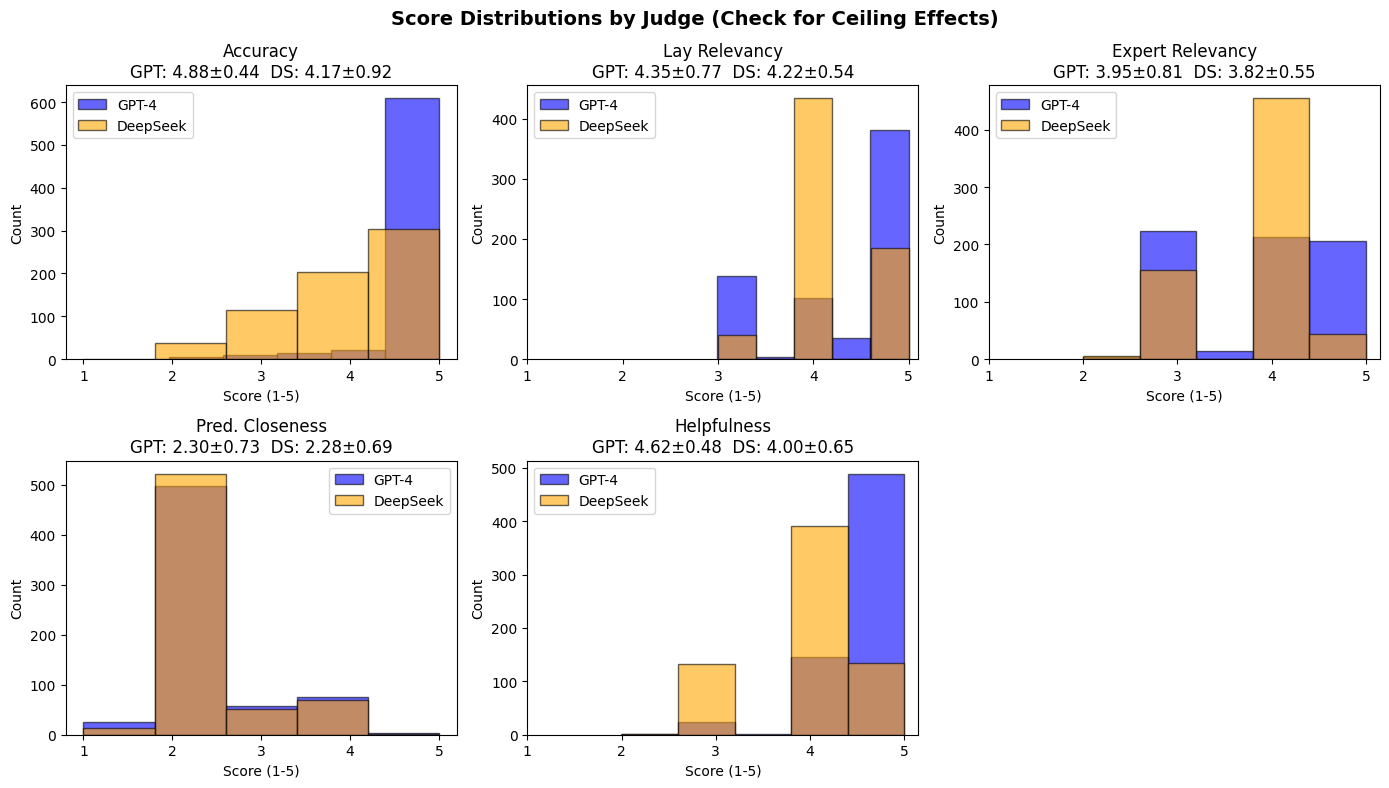


Summary Statistics (GPT-4 Judge):
----------------------------------------------------------------------


,dimension,count,mean,std,min,25%,50%,75%,max
score_accuracy,Accuracy,660.0,4.88,0.44,1.97,5.00,5.00,5.00,5.0
score_lay_user_relevancy,Lay Relevancy,660.0,4.35,0.77,2.99,4.00,4.83,4.98,5.0
score_expert_relevancy,Expert Relevancy,660.0,3.95,0.81,2.00,3.00,3.99,4.98,5.0
score_usefulness_prediction_closeness,Pred. Closeness,660.0,2.30,0.73,1.00,2.00,2.00,2.00,5.0
score_usefulness_explanation_helpfulness,Helpfulness,660.0,4.62,0.48,2.00,4.37,4.85,4.98,5.0


In [169]:
# Score distributions - Check for ceiling effects
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(SCORE_COLS):
    ax = axes[i]
    dim = col.replace('score_', '')
    dim_name = DIM_NAMES[dim]
    
    # Both judges on same plot
    ax.hist(geval_gpt4[col].dropna(), bins=5, alpha=0.6, label='GPT-4', color='blue', edgecolor='black')
    ax.hist(geval_deepseek[col].dropna(), bins=5, alpha=0.6, label='DeepSeek', color='orange', edgecolor='black')
    
    ax.set_xlabel('Score (1-5)')
    ax.set_ylabel('Count')
    ax.set_title(f'{dim_name}\nGPT: {geval_gpt4[col].mean():.2f}±{geval_gpt4[col].std():.2f}  DS: {geval_deepseek[col].mean():.2f}±{geval_deepseek[col].std():.2f}')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend()

# Hide empty subplot
axes[5].axis('off')

plt.suptitle('Score Distributions by Judge (Check for Ceiling Effects)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print("\nSummary Statistics (GPT-4 Judge):")
print("-" * 70)
summary = geval_gpt4[SCORE_COLS].describe().T
summary['dimension'] = [DIM_NAMES[c.replace('score_', '')] for c in summary.index]
summary = summary[['dimension', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(summary.round(2))

### 3.1 Merge Both Judges

We average scores from GPT-4 and DeepSeek judges for each explanation to mitigate potential self-preference bias (LLM judges may favor explanations from their own model family).

In [170]:
# Merge both judges by averaging their scores
# Both dataframes have the same rows in the same order (same 660 explanations)

df_eval = geval_gpt4[FACTOR_COLS].copy()  # Keep factor columns from one

# Average scores from both judges for each dimension
for col in SCORE_COLS:
    df_eval[col] = (geval_gpt4[col] + geval_deepseek[col]) / 2

# Verify
print("Merged evaluation dataset:")
print(f"  Rows: {len(df_eval)}")
print(f"  Factors: {FACTOR_COLS}")
print(f"  Score columns: {SCORE_COLS}")

print(f"\nScore ranges (averaged across both judges):")
for col in SCORE_COLS:
    dim = col.replace('score_', '')
    print(f"  {DIM_NAMES[dim]}: {df_eval[col].min():.2f} - {df_eval[col].max():.2f} (mean: {df_eval[col].mean():.2f})")

Merged evaluation dataset:
  Rows: 660
  Factors: ['LLM', 'Model', 'XAI', 'Strategy']
  Score columns: ['score_accuracy', 'score_lay_user_relevancy', 'score_expert_relevancy', 'score_usefulness_prediction_closeness', 'score_usefulness_explanation_helpfulness']

Score ranges (averaged across both judges):
  Accuracy: 1.98 - 5.00 (mean: 4.52)
  Lay Relevancy: 3.00 - 5.00 (mean: 4.29)
  Expert Relevancy: 2.50 - 5.00 (mean: 3.88)
  Pred. Closeness: 1.00 - 4.00 (mean: 2.29)
  Helpfulness: 2.49 - 5.00 (mean: 4.31)


In [171]:
# Statistical Helper Functions
# ============================

import subprocess, sys
for pkg in ['scipy', 'statsmodels', 'pingouin']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

from scipy import stats
from scipy.stats import f_oneway, ttest_ind, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import pingouin as pg

# --- Effect Size Functions ---

def cohens_d(g1, g2):
    """Cohen's d effect size for two groups."""
    n1, n2 = len(g1), len(g2)
    var1, var2 = g1.var(), g2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0

def omega_squared(f_stat, df_between, df_within, n_total):
    """
    Omega-squared (ω²) - less biased omnibus effect size for ANOVA.
    Interpretation: 0.01 = small, 0.06 = medium, 0.14 = large
    """
    ss_between = f_stat * df_between * (df_within / (n_total - df_between - 1))
    ms_within = df_within / (n_total - df_between - 1)
    omega_sq = (ss_between - df_between * ms_within) / (ss_between + (n_total - df_between) * ms_within + ms_within)
    return max(0, omega_sq)  # Can be negative for very small effects

def omega_sq_from_anova(*groups):
    """Compute omega-squared directly from group data."""
    k = len(groups)
    n_total = sum(len(g) for g in groups)
    df_between = k - 1
    df_within = n_total - k
    
    # Compute SS
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_within = sum(((g - g.mean())**2).sum() for g in groups)
    
    ms_within = ss_within / df_within
    omega_sq = (ss_between - df_between * ms_within) / (ss_between + ss_within + ms_within)
    return max(0, omega_sq)

def effect_label(d):
    """Interpret Cohen's d."""
    d = abs(d)
    if d < 0.2: return "negl."
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else: return "large"

def omega_label(w2):
    """Interpret omega-squared."""
    if w2 < 0.01: return "negl."
    elif w2 < 0.06: return "small"
    elif w2 < 0.14: return "medium"
    else: return "large"

# --- FDR Correction ---

def fdr_correct(p_values, alpha=0.05):
    """
    Benjamini-Hochberg FDR correction.
    Returns: corrected p-values, reject array
    """
    reject, p_corrected, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    return p_corrected, reject

# --- Welch ANOVA + Games-Howell ---

def welch_anova(data, dv, between):
    """
    Welch's ANOVA - robust to unequal variances.
    Returns F, p, omega-squared
    """
    result = pg.welch_anova(data=data, dv=dv, between=between)
    return result

def games_howell(data, dv, between):
    """
    Games-Howell post-hoc test - robust to unequal variances and sample sizes.
    """
    result = pg.pairwise_gameshowell(data=data, dv=dv, between=between)
    return result

print("Statistical helper functions loaded:")
print("  - cohens_d(g1, g2): Cohen's d effect size")
print("  - omega_sq_from_anova(*groups): ω² omnibus effect size")
print("  - effect_label(d), omega_label(w2): Interpret effect sizes")
print("  - fdr_correct(p_values): Benjamini-Hochberg FDR correction")
print("  - welch_anova(data, dv, between): Welch's ANOVA (robust)")
print("  - games_howell(data, dv, between): Games-Howell post-hoc (robust)")

Statistical helper functions loaded:
  - cohens_d(g1, g2): Cohen's d effect size
  - omega_sq_from_anova(*groups): ω² omnibus effect size
  - effect_label(d), omega_label(w2): Interpret effect sizes
  - fdr_correct(p_values): Benjamini-Hochberg FDR correction
  - welch_anova(data, dv, between): Welch's ANOVA (robust)
  - games_howell(data, dv, between): Games-Howell post-hoc (robust)


*[Run cells below, then document findings here]*
---

## 4. RQ1: Effect of XAI Method on NLE Quality

**Research Question**: Does incorporating XAI (SHAP/LIME) improve the quality of generated explanations compared to no XAI?

**Design**: 3 XAI conditions (SHAP, LIME, None) × 594 explanations (excluding SARIMAX for balanced design, N=198 per group)

---

### Statistical Methods

| Method | Purpose |
|--------|---------|
| **One-way ANOVA** | Test if ANY difference exists among 3 XAI groups |
| **Pairwise t-tests** | Identify WHICH pairs differ (SHAP vs None, LIME vs None, SHAP vs LIME) |
| **Cohen's d** | Effect size: \|d\| < 0.2 = negligible, 0.2-0.5 = small, 0.5-0.8 = medium, > 0.8 = large |
| **Tukey HSD** | Post-hoc test controlling family-wise error rate (appendix) |
| **ANCOVA** | Test XAI effect while controlling for LLM & Strategy (appendix) |

---

### Results

#### Main Finding
**XAI significantly improves only Expert Relevancy; all other dimensions show no effect.**

#### ANOVA Results (overall XAI effect)

| Dimension | F | p | Significant? |
|-----------|---|---|--------------|
| Accuracy | 1.07 | 0.342 | No |
| Lay Relevancy | 0.00 | 0.999 | No |
| **Expert Relevancy** | **6.32** | **0.002** | **Yes** |
| Pred. Closeness | 0.29 | 0.750 | No |
| Helpfulness | 1.57 | 0.209 | No |

#### Expert Relevancy (the only significant dimension)

| Comparison | Δ (mean diff) | Cohen's d | p-value |
|------------|---------------|-----------|---------|
| SHAP vs None | +0.19 | +0.33 (small) | 0.001* |
| LIME vs None | +0.16 | +0.28 (small) | 0.006* |
| SHAP vs LIME | +0.03 | +0.06 (negl.) | 0.558 |

**Interpretation**: Both SHAP and LIME improve Expert Relevancy by ~0.2 points compared to no XAI. Effect size is **small** but statistically significant. SHAP and LIME do not differ from each other.

#### All Other Dimensions
- Effect sizes are **negligible** (|d| < 0.2) for all comparisons
- No statistically significant differences

#### ANCOVA (controlling for LLM & Strategy)
- Expert Relevancy effect **remains significant** and becomes stronger: F=12.93, p<0.001***
- Confirms XAI effect is not confounded by other factors

#### Interaction Effects (XAI × LLM)
- **Lay Relevancy**: Significant interaction (p=0.017) - XAI effect differs across LLMs
- **Expert Relevancy**: Significant interaction (p=0.031) - XAI effect differs across LLMs
- Other dimensions: No significant interaction

---

### Summary for Paper

> XAI methods (SHAP, LIME) significantly improve **Expert Relevancy** compared to no-XAI baseline (ANOVA F(2,591)=6.32, p=0.002). Both SHAP (Δ=+0.19, d=0.33) and LIME (Δ=+0.16, d=0.28) show small but significant improvements, with no difference between them. This effect holds after controlling for LLM and Strategy (ANCOVA F=12.93, p<0.001). However, XAI shows **no significant effect** on the other four dimensions (Accuracy, Lay Relevancy, Prediction Closeness, Helpfulness), with negligible effect sizes (|d|<0.2). Significant XAI×LLM interactions suggest the benefit varies by generator model.

In [172]:
# RQ1: XAI Effect - Descriptive Statistics
# ============================================

# EXCLUDE SARIMAX (only has XAI='none', would confound the comparison)
df_xai = df_eval[df_eval['Model'] != 'SARIMAX'].copy()

print(f"Excluded SARIMAX: {len(df_eval)} → {len(df_xai)} rows")
print(f"XAI groups now balanced: {df_xai.groupby('XAI').size().to_dict()}")

# Compute mean ± std for each XAI level × dimension
xai_stats = df_xai.groupby('XAI')[SCORE_COLS].agg(['mean', 'std', 'count'])

# Flatten column names
xai_stats.columns = ['_'.join(col) for col in xai_stats.columns]

# Create clean display table
print("\n" + "="*80)
print("RQ1: XAI Effect on NLE Quality (Averaged across both judges)")
print("="*80)

# Build results table
results = []
for xai_level in ['shap', 'lime', 'none']:
    row = {'XAI': xai_level.upper() if xai_level != 'none' else 'None'}
    row['N'] = int(df_xai[df_xai['XAI'] == xai_level].shape[0])
    for col in SCORE_COLS:
        dim = col.replace('score_', '')
        mean = xai_stats.loc[xai_level, f'{col}_mean']
        std = xai_stats.loc[xai_level, f'{col}_std']
        row[DIM_NAMES[dim]] = f"{mean:.2f} ± {std:.2f}"
    results.append(row)

results_df = pd.DataFrame(results)
display(results_df)

# Also show just means for quick comparison
print("\nMeans only (for quick comparison):")
means_df = df_xai.groupby('XAI')[SCORE_COLS].mean().round(3)
means_df.columns = [DIM_NAMES[c.replace('score_', '')] for c in means_df.columns]
means_df.index = ['LIME', 'None', 'SHAP']  # Rename index
display(means_df)

Excluded SARIMAX: 660 → 594 rows
XAI groups now balanced: {'lime': 198, 'none': 198, 'shap': 198}

RQ1: XAI Effect on NLE Quality (Averaged across both judges)


,XAI,N,Accuracy,Lay Relevancy,Expert Relevancy,Pred. Closeness,Helpfulness
0,SHAP,198,4.53 ± 0.55,4.32 ± 0.57,3.97 ± 0.59,2.30 ± 0.65,4.30 ± 0.53
1,LIME,198,4.57 ± 0.56,4.31 ± 0.55,3.94 ± 0.57,2.33 ± 0.68,4.31 ± 0.49
2,None,198,4.49 ± 0.60,4.31 ± 0.52,3.78 ± 0.56,2.28 ± 0.65,4.38 ± 0.49



Means only (for quick comparison):


,Accuracy,Lay Relevancy,Expert Relevancy,Pred. Closeness,Helpfulness
LIME,4.573,4.314,3.937,2.330,4.312
None,4.489,4.313,3.779,2.280,4.383
SHAP,4.533,4.316,3.971,2.301,4.300


In [173]:
# RQ1: Statistical Analysis
# =========================

# Groups
shap = df_xai[df_xai['XAI'] == 'shap']
lime = df_xai[df_xai['XAI'] == 'lime']
none = df_xai[df_xai['XAI'] == 'none']

# =====================================================
# FOR MAIN PAPER: ANOVA with ω² + FDR-corrected pairwise
# =====================================================
print("="*80)
print("FOR MAIN PAPER: RQ1 Summary (XAI Effect)")
print("="*80)

# ANOVA with omega-squared
print("\n### ANOVA (overall XAI effect) with ω² ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

anova_results = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    f_stat, p_val = f_oneway(shap[col], lime[col], none[col])
    w2 = omega_sq_from_anova(shap[col].values, lime[col].values, none[col].values)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    anova_results.append({'dim': dim, 'F': f_stat, 'p': p_val, 'w2': w2})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {omega_label(w2):>8} {sig}")

# FDR correction across 5 dimensions
p_values = [r['p'] for r in anova_results]
p_fdr, reject_fdr = fdr_correct(p_values)
print(f"\nFDR-corrected p-values (Benjamini-Hochberg):")
for i, r in enumerate(anova_results):
    sig_fdr = "*" if reject_fdr[i] else ""
    print(f"  {r['dim']:<18} p_raw={r['p']:.4f} → p_FDR={p_fdr[i]:.4f} {sig_fdr}")

# Pairwise comparisons with FDR correction
print("\n### Pairwise Comparisons with Effect Sizes (FDR-corrected) ###")
comparisons = [
    ('SHAP', 'None', shap, none),
    ('LIME', 'None', lime, none),
    ('SHAP', 'LIME', shap, lime)
]

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    print(f"\n{dim}:")
    
    # Collect p-values for FDR correction within this dimension
    pairwise_p = []
    pairwise_info = []
    
    for name1, name2, g1, g2 in comparisons:
        diff = g1[col].mean() - g2[col].mean()
        d = cohens_d(g1[col], g2[col])
        t, p = ttest_ind(g1[col], g2[col])
        pairwise_p.append(p)
        pairwise_info.append((name1, name2, diff, d, p))
    
    # FDR correct pairwise comparisons
    p_fdr_pair, reject_pair = fdr_correct(pairwise_p)
    
    for i, (name1, name2, diff, d, p_raw) in enumerate(pairwise_info):
        sig = "*" if reject_pair[i] else ""
        print(f"  {name1:4} vs {name2:4}: Δ={diff:+.3f}, d={d:+.3f} ({effect_label(d):6}), p={p_raw:.3f}, p_FDR={p_fdr_pair[i]:.3f}{sig}")

# =====================================================
# FOR APPENDIX: Tukey HSD (controls FWER)
# =====================================================
print("\n" + "="*80)
print("FOR APPENDIX: Tukey HSD Post-hoc Tests (FWER-controlled)")
print("="*80)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    tukey = pairwise_tukeyhsd(df_xai[col], df_xai['XAI'], alpha=0.05)
    print(f"\n{dim}:")
    print(tukey.summary())

FOR MAIN PAPER: RQ1 Summary (XAI Effect)

### ANOVA (overall XAI effect) with ω² ###
Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy               1.07     0.3424    0.000    negl. 
Lay Relevancy          0.00     0.9985    0.000    negl. 
Expert Relevancy       6.32     0.0019    0.018    small **
Pred. Closeness        0.29     0.7499    0.000    negl. 
Helpfulness            1.57     0.2089    0.002    negl. 

FDR-corrected p-values (Benjamini-Hochberg):
  Accuracy           p_raw=0.3424 → p_FDR=0.5706 
  Lay Relevancy      p_raw=0.9985 → p_FDR=0.9985 
  Expert Relevancy   p_raw=0.0019 → p_FDR=0.0097 *
  Pred. Closeness    p_raw=0.7499 → p_FDR=0.9373 
  Helpfulness        p_raw=0.2089 → p_FDR=0.5222 

### Pairwise Comparisons with Effect Sizes (FDR-corrected) ###

Accuracy:
  SHAP vs None: Δ=+0.044, d=+0.077 (negl. ), p=0.445, p_FDR=0.479
  LIME vs None: Δ=+0.084, d=+0.145 (negl. ), p=0.149, p_FDR=0.4

In [174]:
# RQ1: Robustness Check - Welch ANOVA + Games-Howell
# ===================================================
# (Robust to unequal variances - for appendix)

print("="*80)
print("FOR APPENDIX: Robustness Check - Welch ANOVA + Games-Howell")
print("="*80)
print("(Robust to heterogeneous variances and unequal sample sizes)\n")

# Welch ANOVA
print("### Welch ANOVA ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'Sig'}")
print("-"*45)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    welch_result = welch_anova(data=df_xai, dv=col, between='XAI')
    f_stat = welch_result['F'].values[0]
    p_val = welch_result['p-unc'].values[0]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {sig}")

# Games-Howell post-hoc (only for significant dimensions)
print("\n### Games-Howell Post-hoc (for Expert Relevancy - the significant dimension) ###")
col = 'score_expert_relevancy'
gh_result = games_howell(data=df_xai, dv=col, between='XAI')
display(gh_result[['A', 'B', 'mean(A)', 'mean(B)', 'diff', 'se', 'T', 'df', 'pval', 'hedges']])

FOR APPENDIX: Robustness Check - Welch ANOVA + Games-Howell
(Robust to heterogeneous variances and unequal sample sizes)

### Welch ANOVA ###
Dimension                 F          p Sig
---------------------------------------------
Accuracy               1.04     0.3538 
Lay Relevancy          0.00     0.9985 
Expert Relevancy       6.45     0.0017 **
Pred. Closeness        0.28     0.7545 
Helpfulness            1.60     0.2031 

### Games-Howell Post-hoc (for Expert Relevancy - the significant dimension) ###


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,lime,none,3.936938,3.778779,0.158159,0.056820,2.783533,393.663383,0.015525,0.279223
1,lime,shap,3.936938,3.971368,-0.034430,0.058677,-0.586773,393.521342,0.827295,-0.058861
2,none,shap,3.778779,3.971368,-0.192589,0.057867,-3.328156,392.390120,0.002747,-0.333855


In [175]:
# RQ1: Multi-factor Analysis (FOR APPENDIX)
# ==========================================

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

print("="*80)
print("FOR APPENDIX: Multi-factor Analysis")
print("="*80)

# Factorial Linear Model: XAI effect controlling for other factors
print("\n### Factorial Linear Model: XAI effect controlling for LLM & Strategy ###")
print("Model: Score ~ XAI + LLM + Strategy (Type II SS)")
print("Note: This is factorial ANOVA with categorical factors, not ANCOVA\n")

print(f"{'Dimension':<18} {'XAI F':>10} {'XAI p':>12} {'Sig':>6}")
print("-"*50)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_xai['y'] = df_xai[col]
    model = ols('y ~ C(XAI) + C(LLM) + C(Strategy)', data=df_xai).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(XAI)', 'F'], aov.loc['C(XAI)', 'PR(>F)']
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{dim:<18} {f:>10.2f} {p:>12.4f} {sig:>6}")

# Interaction test with ω²
print("\n### XAI × LLM Interaction Test ###")
print("(Tests if XAI effect differs across LLMs)\n")

print(f"{'Dimension':<18} {'Interaction F':>14} {'p':>12} {'ω²':>8} {'Sig':>6}")
print("-"*65)

interaction_results = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_xai['y'] = df_xai[col]
    model = ols('y ~ C(XAI) * C(LLM)', data=df_xai).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(XAI):C(LLM)', 'F'], aov.loc['C(XAI):C(LLM)', 'PR(>F)']
    
    # Compute partial omega-squared for interaction
    ss_int = aov.loc['C(XAI):C(LLM)', 'sum_sq']
    ss_res = aov.loc['Residual', 'sum_sq']
    df_int = aov.loc['C(XAI):C(LLM)', 'df']
    ms_res = aov.loc['Residual', 'sum_sq'] / aov.loc['Residual', 'df']
    n = len(df_xai)
    w2 = max(0, (ss_int - df_int * ms_res) / (ss_int + ss_res + ms_res))
    
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    interaction_results.append({'dim': dim, 'col': col, 'F': f, 'p': p, 'w2': w2, 'sig': p < 0.05})
    print(f"{dim:<18} {f:>14.2f} {p:>12.4f} {w2:>8.3f} {sig:>6}")

df_xai.drop('y', axis=1, inplace=True)

FOR APPENDIX: Multi-factor Analysis

### Factorial Linear Model: XAI effect controlling for LLM & Strategy ###
Model: Score ~ XAI + LLM + Strategy (Type II SS)
Note: This is factorial ANOVA with categorical factors, not ANCOVA

Dimension               XAI F        XAI p    Sig
--------------------------------------------------
Accuracy                 1.57       0.2085       
Lay Relevancy            0.00       0.9976       
Expert Relevancy        12.93       0.0000    ***
Pred. Closeness          0.29       0.7497       
Helpfulness              2.98       0.0514       

### XAI × LLM Interaction Test ###
(Tests if XAI effect differs across LLMs)

Dimension           Interaction F            p       ω²    Sig
-----------------------------------------------------------------
Accuracy                     2.25       0.0624    0.008       
Lay Relevancy                3.05       0.0168    0.014      *
Expert Relevancy             2.68       0.0310    0.011      *
Pred. Closeness         

FOR APPENDIX: Interaction Plots + Simple Effects

Significant XAI×LLM interactions found for: ['Lay Relevancy', 'Expert Relevancy']


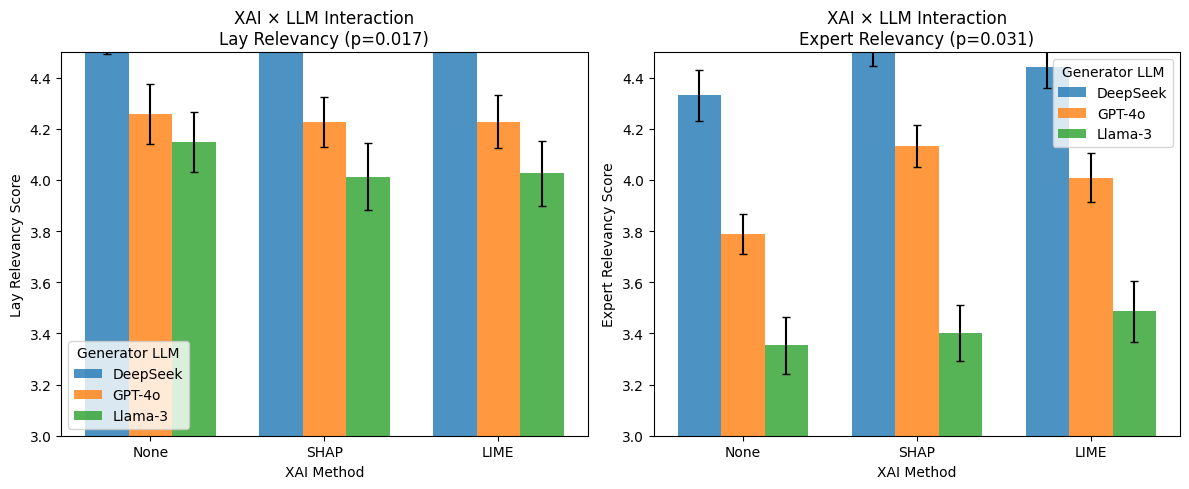


### Simple Effects: XAI effect within each LLM ###

Lay Relevancy:
  GPT-4o      : F=0.11, p=0.893
      SHAP=4.23, LIME=4.23, None=4.26
  Llama-3     : F=1.40, p=0.248
      SHAP=4.01, LIME=4.03, None=4.15
  DeepSeek    : F=7.05, p=0.001*
      SHAP=4.84, LIME=4.81, None=4.61

Expert Relevancy:
  GPT-4o      : F=16.01, p=0.000*
      SHAP=4.13, LIME=4.01, None=3.79
  Llama-3     : F=1.36, p=0.258
      SHAP=3.40, LIME=3.49, None=3.35
  DeepSeek    : F=4.64, p=0.011*
      SHAP=4.51, LIME=4.44, None=4.33


In [176]:
# RQ1: Interaction Plots + Simple Effects
# ========================================

import matplotlib.pyplot as plt

# Only plot for dimensions with significant interactions
sig_interactions = [r for r in interaction_results if r['sig']]

if sig_interactions:
    print("="*80)
    print("FOR APPENDIX: Interaction Plots + Simple Effects")
    print("="*80)
    print(f"\nSignificant XAI×LLM interactions found for: {[r['dim'] for r in sig_interactions]}")
    
    # Create interaction plots
    fig, axes = plt.subplots(1, len(sig_interactions), figsize=(6*len(sig_interactions), 5))
    if len(sig_interactions) == 1:
        axes = [axes]
    
    LLM_NAMES_SHORT = {'GPT': 'GPT-4o', 'L3_LOCAL': 'Llama-3', 'DEEPSEEK': 'DeepSeek'}
    XAI_ORDER = ['none', 'shap', 'lime']
    LLM_ORDER = ['DEEPSEEK', 'GPT', 'L3_LOCAL']
    
    for ax, result in zip(axes, sig_interactions):
        col = result['col']
        dim = result['dim']
        
        # Compute means for interaction plot
        means = df_xai.groupby(['XAI', 'LLM'])[col].mean().unstack()
        sems = df_xai.groupby(['XAI', 'LLM'])[col].sem().unstack()
        
        # Reorder
        means = means.loc[XAI_ORDER, LLM_ORDER]
        sems = sems.loc[XAI_ORDER, LLM_ORDER]
        
        # Plot
        x = np.arange(len(XAI_ORDER))
        width = 0.25
        
        for i, llm in enumerate(LLM_ORDER):
            ax.bar(x + i*width, means[llm], width, 
                   yerr=1.96*sems[llm], capsize=3,
                   label=LLM_NAMES_SHORT[llm], alpha=0.8)
        
        ax.set_xlabel('XAI Method')
        ax.set_ylabel(f'{dim} Score')
        ax.set_title(f'XAI × LLM Interaction\n{dim} (p={result["p"]:.3f})')
        ax.set_xticks(x + width)
        ax.set_xticklabels(['None', 'SHAP', 'LIME'])
        ax.legend(title='Generator LLM')
        ax.set_ylim(3.0, 4.5)
    
    plt.tight_layout()
    plt.savefig('figures/rq1_interaction_xai_llm.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Simple effects: XAI effect within each LLM
    print("\n### Simple Effects: XAI effect within each LLM ###")
    
    for result in sig_interactions:
        col = result['col']
        dim = result['dim']
        print(f"\n{dim}:")
        
        for llm in ['GPT', 'L3_LOCAL', 'DEEPSEEK']:
            llm_data = df_xai[df_xai['LLM'] == llm]
            shap_llm = llm_data[llm_data['XAI'] == 'shap'][col]
            lime_llm = llm_data[llm_data['XAI'] == 'lime'][col]
            none_llm = llm_data[llm_data['XAI'] == 'none'][col]
            
            # One-way ANOVA within this LLM
            f_stat, p_val = f_oneway(shap_llm, lime_llm, none_llm)
            sig = "*" if p_val < 0.05 else ""
            
            print(f"  {LLM_NAMES_SHORT[llm]:12}: F={f_stat:.2f}, p={p_val:.3f}{sig}")
            print(f"      SHAP={shap_llm.mean():.2f}, LIME={lime_llm.mean():.2f}, None={none_llm.mean():.2f}")
else:
    print("No significant XAI×LLM interactions - skipping interaction plots.")

In [177]:
# RQ1: Generate LaTeX Table
# ==========================

def generate_xai_latex_table(df, score_cols, dim_names):
    """Generate LaTeX table for XAI comparison."""
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{Effect of XAI method on NLE quality (mean $\pm$ SD). Scores averaged across GPT-4 and DeepSeek judges. SARIMAX excluded (only supports ``none''). Bold = best per dimension.}")
    lines.append(r"  \label{tab:xai_effect}")
    lines.append(r"  \begin{tabular}{@{}lccccc@{}}")
    lines.append(r"    \toprule")
    
    # Header
    dim_short = ['Accuracy', 'Lay Rel.', 'Expert Rel.', 'Pred. Close.', 'Helpful.']
    lines.append(r"    \textbf{XAI} & " + " & ".join([f"\\textbf{{{d}}}" for d in dim_short]) + r" \\")
    lines.append(r"    \midrule")
    
    # Compute stats
    stats = df.groupby('XAI')[score_cols].agg(['mean', 'std'])
    
    # Find best (highest) per dimension
    means_only = df.groupby('XAI')[score_cols].mean()
    best_per_dim = means_only.idxmax()
    
    # Rows
    xai_order = ['shap', 'lime', 'none']
    xai_display = {'shap': 'SHAP', 'lime': 'LIME', 'none': 'None'}
    
    for xai in xai_order:
        row_parts = [xai_display[xai]]
        for col in score_cols:
            mean = stats.loc[xai, (col, 'mean')]
            std = stats.loc[xai, (col, 'std')]
            if best_per_dim[col] == xai:
                row_parts.append(f"\\textbf{{{mean:.2f}}}$\\pm${std:.2f}")
            else:
                row_parts.append(f"{mean:.2f}$\\pm${std:.2f}")
        lines.append(f"    {' & '.join(row_parts)} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

# Use df_xai (excludes SARIMAX)
latex_xai_table = generate_xai_latex_table(df_xai, SCORE_COLS, DIM_NAMES)
print("LaTeX Table for RQ1 (XAI Effect):")
print("="*80)
print(latex_xai_table)

LaTeX Table for RQ1 (XAI Effect):
\begin{table}[t]
  \centering
  \small
  \caption{Effect of XAI method on NLE quality (mean $\pm$ SD). Scores averaged across GPT-4 and DeepSeek judges. SARIMAX excluded (only supports ``none''). Bold = best per dimension.}
  \label{tab:xai_effect}
  \begin{tabular}{@{}lccccc@{}}
    \toprule
    \textbf{XAI} & \textbf{Accuracy} & \textbf{Lay Rel.} & \textbf{Expert Rel.} & \textbf{Pred. Close.} & \textbf{Helpful.} \\
    \midrule
    SHAP & 4.53$\pm$0.55 & \textbf{4.32}$\pm$0.57 & \textbf{3.97}$\pm$0.59 & 2.30$\pm$0.65 & 4.30$\pm$0.53 \\
    LIME & \textbf{4.57}$\pm$0.56 & 4.31$\pm$0.55 & 3.94$\pm$0.57 & \textbf{2.33}$\pm$0.68 & 4.31$\pm$0.49 \\
    None & 4.49$\pm$0.60 & 4.31$\pm$0.52 & 3.78$\pm$0.56 & 2.28$\pm$0.65 & \textbf{4.38}$\pm$0.49 \\
    \bottomrule
  \end{tabular}
\end{table}


---

## 5. RQ2: Effect of Generator LLM on NLE Quality

**Research Question**: Which LLM (GPT-4o, Llama-3, DeepSeek-R1) produces the highest quality explanations?

**Design**: 3 LLMs × 660 explanations (unbalanced due to CoT exclusion for DeepSeek)

**Note**: These are the **generator** LLMs, not the judges. DeepSeek-R1 has fewer samples because CoT strategies were excluded (native reasoning model).

---

### Statistical Methods

| Method | Purpose |
|--------|---------|
| **One-way ANOVA** | Test if ANY difference exists among 3 LLMs |
| **Pairwise t-tests** | Identify WHICH pairs differ |
| **Cohen's d** | Effect size interpretation |
| **Tukey HSD** | Post-hoc test controlling family-wise error rate |
| **ANCOVA** | Test LLM effect while controlling for XAI & Strategy |

---

### Results

#### Main Finding
**DeepSeek-R1 significantly outperforms GPT-4o and Llama-3 on 4 of 5 dimensions with large effect sizes. This is the strongest effect observed in the study.**

#### ANOVA Results (overall LLM effect)

| Dimension | F | p | Significant? |
|-----------|---|---|--------------|
| **Accuracy** | **81.32** | **<0.001** | **Yes*** |
| **Lay Relevancy** | **107.85** | **<0.001** | **Yes*** |
| **Expert Relevancy** | **332.15** | **<0.001** | **Yes*** |
| Pred. Closeness | 0.97 | 0.381 | No |
| **Helpfulness** | **206.35** | **<0.001** | **Yes*** |

#### Pairwise Comparisons

**Accuracy** (DeepSeek ≈ GPT > Llama):
| Comparison | Δ | Cohen's d | p |
|------------|---|-----------|---|
| DeepSeek vs GPT-4o | -0.02 | -0.04 (negl.) | 0.680 |
| DeepSeek vs Llama-3 | +0.53 | +0.91 (large) | <0.001* |
| GPT-4o vs Llama-3 | +0.54 | +0.95 (large) | <0.001* |

**Lay Relevancy** (DeepSeek >> GPT > Llama):
| Comparison | Δ | Cohen's d | p |
|------------|---|-----------|---|
| DeepSeek vs GPT-4o | +0.51 | +1.17 (large) | <0.001* |
| DeepSeek vs Llama-3 | +0.67 | +1.40 (large) | <0.001* |
| GPT-4o vs Llama-3 | +0.16 | +0.31 (small) | 0.001* |

**Expert Relevancy** (DeepSeek >> GPT >> Llama):
| Comparison | Δ | Cohen's d | p |
|------------|---|-----------|---|
| DeepSeek vs GPT-4o | +0.50 | +1.33 (large) | <0.001* |
| DeepSeek vs Llama-3 | +1.06 | +2.50 (large) | <0.001* |
| GPT-4o vs Llama-3 | +0.56 | +1.24 (large) | <0.001* |

**Pred. Closeness** (no differences):
All pairwise comparisons: p > 0.15, d < 0.14 (negligible)

**Helpfulness** (DeepSeek >> GPT > Llama):
| Comparison | Δ | Cohen's d | p |
|------------|---|-----------|---|
| DeepSeek vs GPT-4o | +0.50 | +1.55 (large) | <0.001* |
| DeepSeek vs Llama-3 | +0.79 | +1.91 (large) | <0.001* |
| GPT-4o vs Llama-3 | +0.28 | +0.66 (medium) | <0.001* |

#### ANCOVA (controlling for XAI & Strategy)
All significant effects **remain highly significant** after controlling for covariates:
- Accuracy: F=95.70, p<0.001***
- Lay Relevancy: F=112.58, p<0.001***
- Expert Relevancy: F=334.24, p<0.001***
- Helpfulness: F=220.51, p<0.001***

#### Interaction Effects (LLM × Strategy)
**Strong significant interactions** across all dimensions (p<0.001 for 4/5):
- Accuracy, Lay Relevancy, Expert Relevancy, Helpfulness: p<0.001***
- Pred. Closeness: p=0.014*

This suggests that the optimal LLM may depend on the prompting strategy used.

---

### Summary for Paper

> LLM choice has the **strongest effect** on NLE quality across all factors tested. DeepSeek-R1 significantly outperforms GPT-4o and Llama-3 on Lay Relevancy (d=1.17–1.40), Expert Relevancy (d=1.33–2.50), and Helpfulness (d=1.55–1.91), with large effect sizes (ANOVA F=81–332, all p<0.001). GPT-4o and DeepSeek-R1 perform equivalently on Accuracy (d=0.04), while both substantially outperform Llama-3 (d≈0.9). Prediction Closeness shows no LLM effect. These differences persist after controlling for XAI method and prompting strategy (ANCOVA all p<0.001). Significant LLM×Strategy interactions (p<0.001) indicate that optimal LLM selection may depend on the prompting approach.

In [178]:
# RQ2: LLM Effect - Descriptive Statistics
# =========================================

# Use full dataset (all models, including SARIMAX)
df_llm = df_eval.copy()

print(f"Full dataset: {len(df_llm)} rows")
print(f"LLM groups: {df_llm.groupby('LLM').size().to_dict()}")
print(f"Note: DeepSeek has fewer samples (CoT strategies excluded)")

# Compute mean ± std for each LLM × dimension
llm_stats = df_llm.groupby('LLM')[SCORE_COLS].agg(['mean', 'std', 'count'])
llm_stats.columns = ['_'.join(col) for col in llm_stats.columns]

# Create clean display table
print("\n" + "="*80)
print("RQ2: LLM Effect on NLE Quality (Averaged across both judges)")
print("="*80)

# Display name mapping
LLM_NAMES = {'GPT': 'GPT-4o', 'L3_LOCAL': 'Llama-3', 'DEEPSEEK': 'DeepSeek-R1'}

# Build results table
results = []
for llm in ['DEEPSEEK', 'GPT', 'L3_LOCAL']:
    row = {'LLM': LLM_NAMES[llm]}
    row['N'] = int(df_llm[df_llm['LLM'] == llm].shape[0])
    for col in SCORE_COLS:
        dim = col.replace('score_', '')
        mean = llm_stats.loc[llm, f'{col}_mean']
        std = llm_stats.loc[llm, f'{col}_std']
        row[DIM_NAMES[dim]] = f"{mean:.2f} ± {std:.2f}"
    results.append(row)

results_df = pd.DataFrame(results)
display(results_df)

# Means only for quick comparison
print("\nMeans only (for quick comparison):")
means_df = df_llm.groupby('LLM')[SCORE_COLS].mean().round(3)
means_df.columns = [DIM_NAMES[c.replace('score_', '')] for c in means_df.columns]
means_df.index = [LLM_NAMES[x] for x in means_df.index]
display(means_df)

Full dataset: 660 rows
LLM groups: {'DEEPSEEK': 180, 'GPT': 240, 'L3_LOCAL': 240}
Note: DeepSeek has fewer samples (CoT strategies excluded)

RQ2: LLM Effect on NLE Quality (Averaged across both judges)


,LLM,N,Accuracy,Lay Relevancy,Expert Relevancy,Pred. Closeness,Helpfulness
0,DeepSeek-R1,180,4.71 ± 0.34,4.72 ± 0.40,4.45 ± 0.32,2.23 ± 0.66,4.78 ± 0.27
1,GPT-4o,240,4.73 ± 0.40,4.20 ± 0.47,3.95 ± 0.41,2.32 ± 0.67,4.28 ± 0.36
2,Llama-3,240,4.18 ± 0.70,4.05 ± 0.54,3.39 ± 0.48,2.30 ± 0.69,3.99 ± 0.49



Means only (for quick comparison):


,Accuracy,Lay Relevancy,Expert Relevancy,Pred. Closeness,Helpfulness
DeepSeek-R1,4.711,4.718,4.448,2.231,4.779
GPT-4o,4.727,4.204,3.948,2.322,4.277
Llama-3,4.184,4.046,3.391,2.299,3.993


In [179]:
# RQ2: Statistical Analysis
# =========================

# Groups
gpt = df_llm[df_llm['LLM'] == 'GPT']
llama = df_llm[df_llm['LLM'] == 'L3_LOCAL']
deepseek = df_llm[df_llm['LLM'] == 'DEEPSEEK']

# =====================================================
# FOR MAIN PAPER: ANOVA with ω² + FDR-corrected pairwise
# =====================================================
print("="*80)
print("FOR MAIN PAPER: RQ2 Summary (LLM Effect)")
print("="*80)

# ANOVA with omega-squared
print("\n### ANOVA (overall LLM effect) with ω² ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

anova_results_llm = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    f_stat, p_val = f_oneway(gpt[col], llama[col], deepseek[col])
    w2 = omega_sq_from_anova(gpt[col].values, llama[col].values, deepseek[col].values)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    anova_results_llm.append({'dim': dim, 'F': f_stat, 'p': p_val, 'w2': w2})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {omega_label(w2):>8} {sig}")

# FDR correction across 5 dimensions
p_values = [r['p'] for r in anova_results_llm]
p_fdr, reject_fdr = fdr_correct(p_values)
print(f"\nFDR-corrected p-values (Benjamini-Hochberg):")
for i, r in enumerate(anova_results_llm):
    sig_fdr = "*" if reject_fdr[i] else ""
    print(f"  {r['dim']:<18} p_raw={r['p']:.4f} → p_FDR={p_fdr[i]:.4f} {sig_fdr}")

# Pairwise comparisons with FDR correction
print("\n### Pairwise Comparisons with Effect Sizes (FDR-corrected) ###")
comparisons = [
    ('DeepSeek', 'GPT-4o', deepseek, gpt),
    ('DeepSeek', 'Llama-3', deepseek, llama),
    ('GPT-4o', 'Llama-3', gpt, llama)
]

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    print(f"\n{dim}:")
    
    pairwise_p = []
    pairwise_info = []
    
    for name1, name2, g1, g2 in comparisons:
        diff = g1[col].mean() - g2[col].mean()
        d = cohens_d(g1[col], g2[col])
        t, p = ttest_ind(g1[col], g2[col])
        pairwise_p.append(p)
        pairwise_info.append((name1, name2, diff, d, p))
    
    p_fdr_pair, reject_pair = fdr_correct(pairwise_p)
    
    for i, (name1, name2, diff, d, p_raw) in enumerate(pairwise_info):
        sig = "*" if reject_pair[i] else ""
        print(f"  {name1:10} vs {name2:10}: Δ={diff:+.3f}, d={d:+.3f} ({effect_label(d):6}), p={p_raw:.3f}, p_FDR={p_fdr_pair[i]:.3f}{sig}")

# =====================================================
# FOR APPENDIX: Tukey HSD (controls FWER)
# =====================================================
print("\n" + "="*80)
print("FOR APPENDIX: Tukey HSD Post-hoc Tests (FWER-controlled)")
print("="*80)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    tukey = pairwise_tukeyhsd(df_llm[col], df_llm['LLM'], alpha=0.05)
    print(f"\n{dim}:")
    print(tukey.summary())

FOR MAIN PAPER: RQ2 Summary (LLM Effect)

### ANOVA (overall LLM effect) with ω² ###
Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy              81.32     0.0000    0.196    large ***
Lay Relevancy        107.85     0.0000    0.245    large ***
Expert Relevancy     332.15     0.0000    0.501    large ***
Pred. Closeness        0.97     0.3811    0.000    negl. 
Helpfulness          206.35     0.0000    0.384    large ***

FDR-corrected p-values (Benjamini-Hochberg):
  Accuracy           p_raw=0.0000 → p_FDR=0.0000 *
  Lay Relevancy      p_raw=0.0000 → p_FDR=0.0000 *
  Expert Relevancy   p_raw=0.0000 → p_FDR=0.0000 *
  Pred. Closeness    p_raw=0.3811 → p_FDR=0.3811 
  Helpfulness        p_raw=0.0000 → p_FDR=0.0000 *

### Pairwise Comparisons with Effect Sizes (FDR-corrected) ###

Accuracy:
  DeepSeek   vs GPT-4o    : Δ=-0.015, d=-0.041 (negl. ), p=0.680, p_FDR=0.680
  DeepSeek   vs Llama-3   : Δ=+0.528, 

In [180]:
# RQ2: Robustness Check - Welch ANOVA + Games-Howell
# ===================================================

print("="*80)
print("FOR APPENDIX: Robustness Check - Welch ANOVA + Games-Howell")
print("="*80)
print("(Robust to heterogeneous variances and unequal sample sizes)\n")

# Welch ANOVA
print("### Welch ANOVA ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'Sig'}")
print("-"*45)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    welch_result = welch_anova(data=df_llm, dv=col, between='LLM')
    f_stat = welch_result['F'].values[0]
    p_val = welch_result['p-unc'].values[0]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {sig}")

# Games-Howell for Expert Relevancy (strongest effect)
print("\n### Games-Howell Post-hoc (Expert Relevancy - strongest LLM effect) ###")
col = 'score_expert_relevancy'
gh_result = games_howell(data=df_llm, dv=col, between='LLM')
display(gh_result[['A', 'B', 'mean(A)', 'mean(B)', 'diff', 'se', 'T', 'df', 'pval', 'hedges']])

FOR APPENDIX: Robustness Check - Welch ANOVA + Games-Howell
(Robust to heterogeneous variances and unequal sample sizes)

### Welch ANOVA ###
Dimension                 F          p Sig
---------------------------------------------
Accuracy              59.81     0.0000 ***
Lay Relevancy        128.21     0.0000 ***
Expert Relevancy     363.22     0.0000 ***
Pred. Closeness        0.99     0.3721 
Helpfulness          261.40     0.0000 ***

### Games-Howell Post-hoc (Expert Relevancy - strongest LLM effect) ###


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,DEEPSEEK,GPT,4.448321,3.947749,0.500572,0.035913,13.938305,417.081527,0.000000e+00,1.326139
1,DEEPSEEK,L3_LOCAL,4.448321,3.390654,1.057666,0.039496,26.778837,412.903962,2.164935e-13,2.495089
2,GPT,L3_LOCAL,3.947749,3.390654,0.557095,0.041051,13.570736,466.020439,0.000000e+00,1.236888


In [181]:
# RQ2: Multi-factor Analysis (FOR APPENDIX)
# ==========================================

print("="*80)
print("FOR APPENDIX: Multi-factor Analysis (LLM)")
print("="*80)

# Factorial Linear Model: LLM effect controlling for XAI & Strategy
print("\n### Factorial Linear Model: LLM effect controlling for XAI & Strategy ###")
print("Model: Score ~ LLM + XAI + Strategy (Type II SS)\n")

print(f"{'Dimension':<18} {'LLM F':>10} {'LLM p':>12} {'Sig':>6}")
print("-"*50)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_llm['y'] = df_llm[col]
    model = ols('y ~ C(LLM) + C(XAI) + C(Strategy)', data=df_llm).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(LLM)', 'F'], aov.loc['C(LLM)', 'PR(>F)']
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{dim:<18} {f:>10.2f} {p:>12.4f} {sig:>6}")

# LLM × Strategy Interaction test
print("\n### LLM × Strategy Interaction Test ###")
print("(Tests if LLM effect differs across strategies)\n")

print(f"{'Dimension':<18} {'Interaction F':>14} {'p':>12} {'ω²':>8} {'Sig':>6}")
print("-"*65)

interaction_results_llm = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_llm['y'] = df_llm[col]
    model = ols('y ~ C(LLM) * C(Strategy)', data=df_llm).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(LLM):C(Strategy)', 'F'], aov.loc['C(LLM):C(Strategy)', 'PR(>F)']
    
    # Partial omega-squared
    ss_int = aov.loc['C(LLM):C(Strategy)', 'sum_sq']
    ss_res = aov.loc['Residual', 'sum_sq']
    df_int = aov.loc['C(LLM):C(Strategy)', 'df']
    ms_res = aov.loc['Residual', 'sum_sq'] / aov.loc['Residual', 'df']
    w2 = max(0, (ss_int - df_int * ms_res) / (ss_int + ss_res + ms_res))
    
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    interaction_results_llm.append({'dim': dim, 'col': col, 'F': f, 'p': p, 'w2': w2, 'sig': p < 0.05})
    print(f"{dim:<18} {f:>14.2f} {p:>12.4f} {w2:>8.3f} {sig:>6}")

df_llm.drop('y', axis=1, inplace=True)

FOR APPENDIX: Multi-factor Analysis (LLM)

### Factorial Linear Model: LLM effect controlling for XAI & Strategy ###
Model: Score ~ LLM + XAI + Strategy (Type II SS)

Dimension               LLM F        LLM p    Sig
--------------------------------------------------
Accuracy                95.70       0.0000    ***
Lay Relevancy          112.58       0.0000    ***
Expert Relevancy       334.24       0.0000    ***
Pred. Closeness          0.59       0.5532       
Helpfulness            220.51       0.0000    ***

### LLM × Strategy Interaction Test ###
(Tests if LLM effect differs across strategies)

Dimension           Interaction F            p       ω²    Sig
-----------------------------------------------------------------
Accuracy                    18.79       0.0000    0.276    ***
Lay Relevancy               19.81       0.0000    0.287    ***
Expert Relevancy            23.23       0.0000    0.323    ***
Pred. Closeness              2.03       0.0140    0.022      *
Helpfulness

In [182]:
# RQ2: Interaction Plots + Simple Effects (LLM × Strategy)
# =========================================================

sig_interactions_llm = [r for r in interaction_results_llm if r['sig']]

if sig_interactions_llm:
    print("="*80)
    print("FOR APPENDIX: LLM × Strategy Interaction - Simple Effects")
    print("="*80)
    print(f"\nSignificant interactions for: {[r['dim'] for r in sig_interactions_llm]}")
    
    # Just show simple effects for one representative dimension (Helpfulness)
    print("\n### Simple Effects: LLM effect within each Strategy (Helpfulness) ###")
    col = 'score_usefulness_explanation_helpfulness'
    
    STRATEGY_NAMES_SHORT = {
        'zero_shot': 'Zero-shot', 'few_shot': 'Few-shot', 
        'cot_zero_shot': 'CoT Zero', 'cot_few_shot': 'CoT Few',
        'role_based': 'Role-based', 'meta_prompting': 'Meta-prompt',
        'reflexion': 'Reflexion', 'self_consistency': 'Self-cons.'
    }
    
    for strategy in df_llm['Strategy'].unique():
        strat_data = df_llm[df_llm['Strategy'] == strategy]
        
        # Check if all LLMs present
        llms_present = strat_data['LLM'].unique()
        if len(llms_present) < 2:
            continue
            
        groups = [strat_data[strat_data['LLM'] == llm][col] for llm in llms_present if len(strat_data[strat_data['LLM'] == llm]) > 0]
        
        if len(groups) >= 2:
            f_stat, p_val = f_oneway(*groups)
            sig = "*" if p_val < 0.05 else ""
            
            means_str = ", ".join([f"{LLM_NAMES.get(llm, llm)}={strat_data[strat_data['LLM'] == llm][col].mean():.2f}" 
                                   for llm in llms_present])
            print(f"  {STRATEGY_NAMES_SHORT.get(strategy, strategy):12}: F={f_stat:.2f}, p={p_val:.3f}{sig}")
            print(f"      {means_str}")
else:
    print("No significant LLM×Strategy interactions.")

FOR APPENDIX: LLM × Strategy Interaction - Simple Effects

Significant interactions for: ['Accuracy', 'Lay Relevancy', 'Expert Relevancy', 'Pred. Closeness', 'Helpfulness']

### Simple Effects: LLM effect within each Strategy (Helpfulness) ###
  CoT Few     : F=7.71, p=0.007*
      GPT-4o=4.40, Llama-3=4.04
  CoT Zero    : F=6.77, p=0.012*
      GPT-4o=4.26, Llama-3=3.97
  Few-shot    : F=19.66, p=0.000*
      GPT-4o=4.45, Llama-3=4.29, DeepSeek-R1=4.86
  Meta-prompt : F=44.64, p=0.000*
      GPT-4o=4.00, Llama-3=3.69, DeepSeek-R1=4.50
  Reflexion   : F=59.11, p=0.000*
      GPT-4o=4.32, Llama-3=3.79, DeepSeek-R1=4.81
  Role-based  : F=40.78, p=0.000*
      GPT-4o=4.26, Llama-3=3.98, DeepSeek-R1=4.82
  Self-cons.  : F=53.99, p=0.000*
      GPT-4o=4.32, Llama-3=4.06, DeepSeek-R1=4.91
  Zero-shot   : F=38.36, p=0.000*
      GPT-4o=4.20, Llama-3=4.12, DeepSeek-R1=4.77


In [183]:
# RQ2: Generate LaTeX Table
# ==========================

def generate_llm_latex_table(df, score_cols, dim_names, llm_names):
    """Generate LaTeX table for LLM comparison."""
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{Effect of generator LLM on NLE quality (mean $\pm$ SD). Scores averaged across GPT-4 and DeepSeek judges. DeepSeek-R1 has fewer samples (CoT strategies excluded). Bold = best per dimension.}")
    lines.append(r"  \label{tab:llm_effect}")
    lines.append(r"  \begin{tabular}{@{}lcccccc@{}}")
    lines.append(r"    \toprule")
    
    # Header
    dim_short = ['Accuracy', 'Lay Rel.', 'Expert Rel.', 'Pred. Close.', 'Helpful.']
    lines.append(r"    \textbf{LLM} & \textbf{N} & " + " & ".join([f"\\textbf{{{d}}}" for d in dim_short]) + r" \\")
    lines.append(r"    \midrule")
    
    # Compute stats
    stats = df.groupby('LLM')[score_cols].agg(['mean', 'std'])
    counts = df.groupby('LLM').size()
    
    # Find best (highest) per dimension
    means_only = df.groupby('LLM')[score_cols].mean()
    best_per_dim = means_only.idxmax()
    
    # Rows - sorted by overall mean score (descending)
    overall_means = means_only.mean(axis=1).sort_values(ascending=False)
    llm_order = overall_means.index.tolist()
    
    for llm in llm_order:
        row_parts = [llm_names[llm], str(counts[llm])]
        for col in score_cols:
            mean = stats.loc[llm, (col, 'mean')]
            std = stats.loc[llm, (col, 'std')]
            if best_per_dim[col] == llm:
                row_parts.append(f"\\textbf{{{mean:.2f}}}$\\pm${std:.2f}")
            else:
                row_parts.append(f"{mean:.2f}$\\pm${std:.2f}")
        lines.append(f"    {' & '.join(row_parts)} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

# Generate LaTeX table
latex_llm_table = generate_llm_latex_table(df_llm, SCORE_COLS, DIM_NAMES, LLM_NAMES)
print("LaTeX Table for RQ2 (LLM Effect):")
print("="*80)
print(latex_llm_table)

LaTeX Table for RQ2 (LLM Effect):
\begin{table}[t]
  \centering
  \small
  \caption{Effect of generator LLM on NLE quality (mean $\pm$ SD). Scores averaged across GPT-4 and DeepSeek judges. DeepSeek-R1 has fewer samples (CoT strategies excluded). Bold = best per dimension.}
  \label{tab:llm_effect}
  \begin{tabular}{@{}lcccccc@{}}
    \toprule
    \textbf{LLM} & \textbf{N} & \textbf{Accuracy} & \textbf{Lay Rel.} & \textbf{Expert Rel.} & \textbf{Pred. Close.} & \textbf{Helpful.} \\
    \midrule
    DeepSeek-R1 & 180 & 4.71$\pm$0.34 & \textbf{4.72}$\pm$0.40 & \textbf{4.45}$\pm$0.32 & 2.23$\pm$0.66 & \textbf{4.78}$\pm$0.27 \\
    GPT-4o & 240 & \textbf{4.73}$\pm$0.40 & 4.20$\pm$0.47 & 3.95$\pm$0.41 & \textbf{2.32}$\pm$0.67 & 4.28$\pm$0.36 \\
    Llama-3 & 240 & 4.18$\pm$0.70 & 4.05$\pm$0.54 & 3.39$\pm$0.48 & 2.30$\pm$0.69 & 3.99$\pm$0.49 \\
    \bottomrule
  \end{tabular}
\end{table}


---

## 6. RQ3: Effect of Prompting Strategy on NLE Quality

**Research Question**: Which prompting strategy produces the highest quality explanations?

**Design**: 8 strategies × 660 explanations (unbalanced: CoT strategies exclude DeepSeek, N=60; others N=90)

**Strategies**:
- Basic: Zero-shot, Few-shot
- Chain-of-Thought: CoT Zero-shot, CoT Few-shot
- Advanced: Role-based, Meta-prompting, Reflexion, Self-consistency

---

### Statistical Methods

| Method | Purpose |
|--------|---------|
| **One-way ANOVA** | Test if ANY difference exists among 8 strategies |
| **Tukey HSD** | Post-hoc pairwise comparisons |
| **Cohen's d** | Effect sizes for key comparisons |
| **ANCOVA** | Control for LLM and XAI |

---

### Results

#### Main Finding
**Self-consistency achieves the highest scores, but Zero-shot is highly competitive. Chain-of-Thought (CoT) hurts rather than helps.**

#### Strategy Ranking (by overall mean score)

| Rank | Strategy | Overall Score |
|------|----------|---------------|
| 1 | **Self-consistency** | **4.00** |
| 2 | Reflexion | 3.94 |
| 3 | Zero-shot | 3.93 |
| 4 | Role-based | 3.91 |
| 5 | Few-shot | 3.87 |
| 6 | CoT Zero | 3.77 |
| 7 | CoT Few | 3.71 |
| 8 | Meta-prompt | 3.66 |

#### ANOVA Results (overall Strategy effect)

| Dimension | F | p | Significant? |
|-----------|---|---|--------------|
| **Accuracy** | **16.75** | **<0.001** | **Yes*** |
| **Lay Relevancy** | **14.28** | **<0.001** | **Yes*** |
| **Expert Relevancy** | **4.80** | **<0.001** | **Yes*** |
| Pred. Closeness | 1.36 | 0.219 | No |
| **Helpfulness** | **8.86** | **<0.001** | **Yes*** |

#### Key Findings

**1. Self-consistency achieves highest scores (but marginal)**
- Self-consistency vs Zero-shot: Mostly negligible differences (d<0.2)
- Only Lay Relevancy shows improvement: Δ=+0.21, d=0.49 (small), p=0.001*
- Other dimensions: p>0.3, d<0.15

**2. Zero-shot is highly competitive**
- Ranks 3rd overall despite being simplest/cheapest
- No significant disadvantage vs. Self-consistency on 4/5 dimensions

**3. CoT hurts rather than helps** (confirming paper claim)
- **CoT Zero vs Zero-shot**:
  - Expert Relevancy: Δ=-0.36, d=-0.62 (medium), p<0.001*
  - Helpfulness: Δ=-0.24, d=-0.56 (medium), p=0.001*
- **CoT Few vs Few-shot**:
  - Lay Relevancy: Δ=-0.18, d=-0.34 (small), p=0.043*
  - Expert Relevancy: Δ=-0.26, d=-0.43 (small), p=0.011*
  - Helpfulness: Δ=-0.31, d=-0.66 (medium), p<0.001*

**4. Meta-prompting performs worst**
- Significantly worse than Zero-shot on multiple dimensions:
  - Accuracy: Δ=-0.48, d=-0.95 (large), p<0.001*
  - Lay Relevancy: Δ=-0.38, d=-0.67 (medium), p<0.001*
  - Helpfulness: Δ=-0.30, d=-0.67 (medium), p<0.001*

#### ANCOVA (controlling for LLM & XAI)
All significant effects **remain significant** after controlling for covariates (all p<0.001 except Pred. Closeness).

---

### Summary for Paper

> Prompting strategy significantly affects NLE quality (ANOVA F=4.8–16.8, p<0.001 for 4/5 dimensions). **Self-consistency** achieves the highest overall score (4.00), but the advantage over **Zero-shot** (3.93) is modest, with only Lay Relevancy showing a significant improvement (d=0.49). Surprisingly, **Chain-of-Thought prompting hurts** performance: CoT Zero-shot underperforms Zero-shot on Expert Relevancy (d=-0.62) and Helpfulness (d=-0.56). **Meta-prompting** performs worst overall (3.66), significantly worse than Zero-shot (d=0.67–0.95). Given the high computational cost of Self-consistency (3718 tokens vs 499 for Zero-shot), Zero-shot represents the best quality-efficiency tradeoff.

In [184]:
# RQ3: Strategy Effect - Descriptive Statistics
# ==============================================

df_strategy = df_eval.copy()

# Strategy display names
STRATEGY_NAMES = {
    'zero_shot': 'Zero-shot',
    'few_shot': 'Few-shot', 
    'cot_zero_shot': 'CoT Zero',
    'cot_few_shot': 'CoT Few',
    'role_based': 'Role-based',
    'meta_prompting': 'Meta-prompt',
    'reflexion': 'Reflexion',
    'self_consistency': 'Self-consistency'
}

print(f"Full dataset: {len(df_strategy)} rows")
print(f"Strategy groups: {df_strategy.groupby('Strategy').size().to_dict()}")
print(f"Note: CoT strategies have N=60 (exclude DeepSeek), others N=90")

# Compute mean ± std for each Strategy × dimension
strategy_stats = df_strategy.groupby('Strategy')[SCORE_COLS].agg(['mean', 'std', 'count'])
strategy_stats.columns = ['_'.join(col) for col in strategy_stats.columns]

print("\n" + "="*80)
print("RQ3: Strategy Effect on NLE Quality (Averaged across both judges)")
print("="*80)

# Build results table sorted by overall mean score
results = []
for strategy in df_strategy['Strategy'].unique():
    row = {'Strategy': STRATEGY_NAMES.get(strategy, strategy)}
    row['N'] = int(df_strategy[df_strategy['Strategy'] == strategy].shape[0])
    for col in SCORE_COLS:
        dim = col.replace('score_', '')
        mean = strategy_stats.loc[strategy, f'{col}_mean']
        std = strategy_stats.loc[strategy, f'{col}_std']
        row[DIM_NAMES[dim]] = f"{mean:.2f} ± {std:.2f}"
    # Compute overall mean for sorting
    row['_overall'] = df_strategy[df_strategy['Strategy'] == strategy][SCORE_COLS].mean().mean()
    results.append(row)

results_df = pd.DataFrame(results).sort_values('_overall', ascending=False)
results_df = results_df.drop('_overall', axis=1).reset_index(drop=True)
display(results_df)

# Means only - sorted by overall score
print("\nMeans only (sorted by overall score):")
means_df = df_strategy.groupby('Strategy')[SCORE_COLS].mean()
means_df.columns = [DIM_NAMES[c.replace('score_', '')] for c in means_df.columns]
means_df['Overall'] = means_df.mean(axis=1)
means_df = means_df.sort_values('Overall', ascending=False).round(3)
means_df.index = [STRATEGY_NAMES.get(x, x) for x in means_df.index]
display(means_df)

Full dataset: 660 rows
Strategy groups: {'cot_few_shot': 60, 'cot_zero_shot': 60, 'few_shot': 90, 'meta_prompting': 90, 'reflexion': 90, 'role_based': 90, 'self_consistency': 90, 'zero_shot': 90}
Note: CoT strategies have N=60 (exclude DeepSeek), others N=90

RQ3: Strategy Effect on NLE Quality (Averaged across both judges)


,Strategy,N,Accuracy,Lay Relevancy,Expert Relevancy,Pred. Closeness,Helpfulness
0,Self-consistency,90,4.72 ± 0.42,4.57 ± 0.34,4.05 ± 0.53,2.25 ± 0.65,4.43 ± 0.48
1,Reflexion,90,4.74 ± 0.38,4.39 ± 0.54,3.96 ± 0.63,2.28 ± 0.68,4.31 ± 0.56
2,Zero-shot,90,4.70 ± 0.41,4.36 ± 0.52,4.00 ± 0.63,2.25 ± 0.67,4.36 ± 0.43
3,Role-based,90,4.58 ± 0.50,4.48 ± 0.49,3.84 ± 0.56,2.27 ± 0.67,4.36 ± 0.51
4,Few-shot,90,4.33 ± 0.72,4.20 ± 0.55,3.94 ± 0.60,2.35 ± 0.71,4.53 ± 0.43
5,CoT Zero,60,4.71 ± 0.43,4.19 ± 0.50,3.64 ± 0.48,2.21 ± 0.65,4.12 ± 0.45
6,CoT Few,60,4.13 ± 0.77,4.02 ± 0.51,3.68 ± 0.62,2.51 ± 0.68,4.22 ± 0.53
7,Meta-prompt,90,4.22 ± 0.58,3.97 ± 0.62,3.80 ± 0.57,2.24 ± 0.67,4.06 ± 0.47



Means only (sorted by overall score):


,Accuracy,Lay Relevancy,Expert Relevancy,Pred. Closeness,Helpfulness,Overall
Self-consistency,4.717,4.570,4.053,2.246,4.432,4.003
Reflexion,4.743,4.386,3.957,2.283,4.306,3.935
Zero-shot,4.697,4.357,3.995,2.246,4.362,3.932
Role-based,4.580,4.481,3.843,2.269,4.356,3.906
Few-shot,4.331,4.197,3.940,2.353,4.531,3.870
CoT Zero,4.714,4.189,3.637,2.206,4.118,3.773
CoT Few,4.132,4.016,3.679,2.511,4.223,3.712
Meta-prompt,4.218,3.974,3.801,2.242,4.062,3.660


In [185]:
# RQ3: Statistical Analysis
# =========================

# Get strategy groups
strategies = df_strategy['Strategy'].unique()
strategy_groups = {s: df_strategy[df_strategy['Strategy'] == s] for s in strategies}

# =====================================================
# FOR MAIN PAPER: ANOVA with ω² + FDR-corrected
# =====================================================
print("="*80)
print("FOR MAIN PAPER: RQ3 Summary (Strategy Effect)")
print("="*80)

# ANOVA with omega-squared
print("\n### ANOVA (overall Strategy effect) with ω² ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

anova_results_strat = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    groups = [strategy_groups[s][col].values for s in strategies]
    f_stat, p_val = f_oneway(*[strategy_groups[s][col] for s in strategies])
    w2 = omega_sq_from_anova(*groups)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    anova_results_strat.append({'dim': dim, 'F': f_stat, 'p': p_val, 'w2': w2})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {omega_label(w2):>8} {sig}")

# FDR correction
p_values = [r['p'] for r in anova_results_strat]
p_fdr, reject_fdr = fdr_correct(p_values)
print(f"\nFDR-corrected p-values:")
for i, r in enumerate(anova_results_strat):
    sig_fdr = "*" if reject_fdr[i] else ""
    print(f"  {r['dim']:<18} p_raw={r['p']:.4f} → p_FDR={p_fdr[i]:.4f} {sig_fdr}")

# Key comparisons with FDR correction
print("\n### Key Pairwise Comparisons (FDR-corrected) ###")
print("Testing: Self-consistency vs Zero-shot, CoT vs baseline\n")

key_comparisons = [
    ('Self-consistency', 'Zero-shot', 'self_consistency', 'zero_shot'),
    ('CoT Zero', 'Zero-shot', 'cot_zero_shot', 'zero_shot'),
    ('CoT Few', 'Few-shot', 'cot_few_shot', 'few_shot'),
    ('Reflexion', 'Zero-shot', 'reflexion', 'zero_shot'),
    ('Meta-prompt', 'Zero-shot', 'meta_prompting', 'zero_shot'),
]

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    print(f"\n{dim}:")
    
    pairwise_p = []
    pairwise_info = []
    
    for name1, name2, s1, s2 in key_comparisons:
        g1, g2 = strategy_groups[s1][col], strategy_groups[s2][col]
        diff = g1.mean() - g2.mean()
        d = cohens_d(g1, g2)
        t, p = ttest_ind(g1, g2)
        pairwise_p.append(p)
        pairwise_info.append((name1, name2, diff, d, p))
    
    p_fdr_pair, reject_pair = fdr_correct(pairwise_p)
    
    for i, (name1, name2, diff, d, p_raw) in enumerate(pairwise_info):
        sig = "*" if reject_pair[i] else ""
        print(f"  {name1:16} vs {name2:10}: Δ={diff:+.3f}, d={d:+.3f} ({effect_label(d):6}), p_FDR={p_fdr_pair[i]:.3f}{sig}")

# =====================================================
# FOR APPENDIX: Tukey HSD (showing significant only)
# =====================================================
print("\n" + "="*80)
print("FOR APPENDIX: Tukey HSD (significant pairs only)")
print("="*80)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    tukey = pairwise_tukeyhsd(df_strategy[col], df_strategy['Strategy'], alpha=0.05)
    
    sig_count = sum(tukey.reject)
    print(f"\n{dim}: {sig_count} significant pairs")

FOR MAIN PAPER: RQ3 Summary (Strategy Effect)

### ANOVA (overall Strategy effect) with ω² ###
Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy              16.75     0.0000    0.143    large ***
Lay Relevancy         14.28     0.0000    0.123   medium ***
Expert Relevancy       4.80     0.0000    0.039    small ***
Pred. Closeness        1.36     0.2192    0.004    negl. 
Helpfulness            8.86     0.0000    0.077   medium ***

FDR-corrected p-values:
  Accuracy           p_raw=0.0000 → p_FDR=0.0000 *
  Lay Relevancy      p_raw=0.0000 → p_FDR=0.0000 *
  Expert Relevancy   p_raw=0.0000 → p_FDR=0.0000 *
  Pred. Closeness    p_raw=0.2192 → p_FDR=0.2192 
  Helpfulness        p_raw=0.0000 → p_FDR=0.0000 *

### Key Pairwise Comparisons (FDR-corrected) ###
Testing: Self-consistency vs Zero-shot, CoT vs baseline


Accuracy:
  Self-consistency vs Zero-shot : Δ=+0.020, d=+0.047 (negl. ), p_FDR=0.806
  CoT Zer

In [186]:
# RQ3: Robustness Check - Welch ANOVA
# ====================================

print("="*80)
print("FOR APPENDIX: Robustness Check - Welch ANOVA")
print("="*80)

print("\n### Welch ANOVA (robust to heterogeneous variances) ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'Sig'}")
print("-"*45)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    welch_result = welch_anova(data=df_strategy, dv=col, between='Strategy')
    f_stat = welch_result['F'].values[0]
    p_val = welch_result['p-unc'].values[0]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {sig}")

FOR APPENDIX: Robustness Check - Welch ANOVA

### Welch ANOVA (robust to heterogeneous variances) ###
Dimension                 F          p Sig
---------------------------------------------
Accuracy              14.42     0.0000 ***
Lay Relevancy         16.47     0.0000 ***
Expert Relevancy       5.46     0.0000 ***
Pred. Closeness        1.32     0.2410 
Helpfulness            9.79     0.0000 ***


In [187]:
# RQ3: Multi-factor Analysis (FOR APPENDIX)
# ==========================================

print("="*80)
print("FOR APPENDIX: Multi-factor Analysis (Strategy)")
print("="*80)

# Factorial Linear Model
print("\n### Factorial Linear Model: Strategy effect controlling for LLM & XAI ###")
print("Model: Score ~ Strategy + LLM + XAI (Type II SS)\n")

print(f"{'Dimension':<18} {'Strategy F':>12} {'Strategy p':>14} {'Sig':>6}")
print("-"*55)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_strategy['y'] = df_strategy[col]
    model = ols('y ~ C(Strategy) + C(LLM) + C(XAI)', data=df_strategy).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(Strategy)', 'F'], aov.loc['C(Strategy)', 'PR(>F)']
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{dim:<18} {f:>12.2f} {p:>14.4f} {sig:>6}")

df_strategy.drop('y', axis=1, inplace=True)

# Strategy ranking
print("\n### Strategy Ranking by Overall Mean Score ###")
overall_means = df_strategy.groupby('Strategy')[SCORE_COLS].mean().mean(axis=1).sort_values(ascending=False)
for i, (strat, mean) in enumerate(overall_means.items(), 1):
    print(f"  {i}. {STRATEGY_NAMES.get(strat, strat):18} {mean:.3f}")

FOR APPENDIX: Multi-factor Analysis (Strategy)

### Factorial Linear Model: Strategy effect controlling for LLM & XAI ###
Model: Score ~ Strategy + LLM + XAI (Type II SS)

Dimension            Strategy F     Strategy p    Sig
-------------------------------------------------------
Accuracy                  20.80         0.0000    ***
Lay Relevancy             15.66         0.0000    ***
Expert Relevancy           3.55         0.0009    ***
Pred. Closeness            1.25         0.2725       
Helpfulness               12.06         0.0000    ***

### Strategy Ranking by Overall Mean Score ###
  1. Self-consistency   4.003
  2. Reflexion          3.935
  3. Zero-shot          3.932
  4. Role-based         3.906
  5. Few-shot           3.870
  6. CoT Zero           3.773
  7. CoT Few            3.712
  8. Meta-prompt        3.660


In [188]:
# RQ3: Generate LaTeX Table
# ==========================

def generate_strategy_latex_table(df, score_cols, dim_names, strategy_names):
    """Generate LaTeX table for Strategy comparison."""
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{Effect of prompting strategy on NLE quality (mean $\pm$ SD). Sorted by overall score. Scores averaged across both judges. CoT strategies exclude DeepSeek-R1. Bold = best per dimension.}")
    lines.append(r"  \label{tab:strategy_effect}")
    lines.append(r"  \begin{tabular}{@{}lcccccc@{}}")
    lines.append(r"    \toprule")
    
    # Header
    dim_short = ['Accuracy', 'Lay Rel.', 'Expert Rel.', 'Pred. Close.', 'Helpful.']
    lines.append(r"    \textbf{Strategy} & \textbf{N} & " + " & ".join([f"\\textbf{{{d}}}" for d in dim_short]) + r" \\")
    lines.append(r"    \midrule")
    
    # Compute stats
    stats = df.groupby('Strategy')[score_cols].agg(['mean', 'std'])
    counts = df.groupby('Strategy').size()
    
    # Find best (highest) per dimension
    means_only = df.groupby('Strategy')[score_cols].mean()
    best_per_dim = means_only.idxmax()
    
    # Sort by overall mean score (descending)
    overall_means = means_only.mean(axis=1).sort_values(ascending=False)
    strategy_order = overall_means.index.tolist()
    
    for strat in strategy_order:
        row_parts = [strategy_names.get(strat, strat), str(counts[strat])]
        for col in score_cols:
            mean = stats.loc[strat, (col, 'mean')]
            std = stats.loc[strat, (col, 'std')]
            if best_per_dim[col] == strat:
                row_parts.append(f"\\textbf{{{mean:.2f}}}$\\pm${std:.2f}")
            else:
                row_parts.append(f"{mean:.2f}$\\pm${std:.2f}")
        lines.append(f"    {' & '.join(row_parts)} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

# Generate LaTeX table
latex_strategy_table = generate_strategy_latex_table(df_strategy, SCORE_COLS, DIM_NAMES, STRATEGY_NAMES)
print("LaTeX Table for RQ3 (Strategy Effect):")
print("="*80)
print(latex_strategy_table)

LaTeX Table for RQ3 (Strategy Effect):
\begin{table}[t]
  \centering
  \small
  \caption{Effect of prompting strategy on NLE quality (mean $\pm$ SD). Sorted by overall score. Scores averaged across both judges. CoT strategies exclude DeepSeek-R1. Bold = best per dimension.}
  \label{tab:strategy_effect}
  \begin{tabular}{@{}lcccccc@{}}
    \toprule
    \textbf{Strategy} & \textbf{N} & \textbf{Accuracy} & \textbf{Lay Rel.} & \textbf{Expert Rel.} & \textbf{Pred. Close.} & \textbf{Helpful.} \\
    \midrule
    Self-consistency & 90 & 4.72$\pm$0.42 & \textbf{4.57}$\pm$0.34 & \textbf{4.05}$\pm$0.53 & 2.25$\pm$0.65 & 4.43$\pm$0.48 \\
    Reflexion & 90 & \textbf{4.74}$\pm$0.38 & 4.39$\pm$0.54 & 3.96$\pm$0.63 & 2.28$\pm$0.68 & 4.31$\pm$0.56 \\
    Zero-shot & 90 & 4.70$\pm$0.41 & 4.36$\pm$0.52 & 4.00$\pm$0.63 & 2.25$\pm$0.67 & 4.36$\pm$0.43 \\
    Role-based & 90 & 4.58$\pm$0.50 & 4.48$\pm$0.49 & 3.84$\pm$0.56 & 2.27$\pm$0.67 & 4.36$\pm$0.51 \\
    Few-shot & 90 & 4.33$\pm$0.72 & 4.20$\pm$0.5

---

## 7. RQ4: Effect of ML Model on NLE Quality

**Research Question**: Does the underlying ML model quality affect NLE quality? Do classical models (SARIMAX) perform differently than ML models?

**Design**: 4 models × 660 explanations (unbalanced: SARIMAX N=66 only XAI='none'; ML models N=198 each)

**Models** (ordered by predictive performance R²):
1. XGBoost (R²=0.78) - best ML model
2. Random Forest (R²=0.72)
3. MLP (R²=0.64)
4. SARIMAX (R²=0.42) - classical time series model

---

### Statistical Methods

| Method | Purpose |
|--------|---------|
| **One-way ANOVA** | Test if ANY difference exists among 4 models |
| **Tukey HSD** | Post-hoc pairwise comparisons |
| **Cohen's d** | Effect sizes |
| **SARIMAX vs ML (pooled)** | Test classical vs ML difference |
| **Correlation** | Model R² vs NLE quality |

---

### Results

#### Main Finding
**Better-performing ML models yield higher NLE quality. XGBoost (R²=0.78) achieves the best NLE scores. SARIMAX struggles despite inherent interpretability.**

#### Model Ranking (by overall mean score)

| Rank | Model | R² | Overall NLE |
|------|-------|-----|-------------|
| 1 | **XGBoost** | **0.78** | **3.91** |
| 2 | MLP | 0.64 | 3.89 |
| 3 | Random Forest | 0.72 | 3.83 |
| 4 | SARIMAX | 0.42 | 3.71 |

#### ANOVA Results (overall Model effect)

| Dimension | F | p | Significant? |
|-----------|---|---|--------------|
| Accuracy | 0.71 | 0.547 | No |
| **Lay Relevancy** | **26.70** | **<0.001** | **Yes*** |
| **Expert Relevancy** | **4.61** | **0.003** | **Yes** |
| **Pred. Closeness** | **35.02** | **<0.001** | **Yes*** |
| **Helpfulness** | **7.79** | **<0.001** | **Yes*** |

#### SARIMAX vs ML Models (pooled)
Testing whether classical SARIMAX performs differently than ML models:

| Dimension | SARIMAX | ML (pooled) | Δ | Cohen's d | p |
|-----------|---------|-------------|---|-----------|---|
| Accuracy | 4.47 | 4.53 | -0.07 | -0.11 (negl.) | 0.378 |
| **Lay Relevancy** | 4.04 | 4.31 | **-0.28** | **-0.51 (medium)** | **<0.001*** |
| Expert Relevancy | 3.76 | 3.90 | -0.14 | -0.24 (small) | 0.069 |
| Pred. Closeness | 2.16 | 2.30 | -0.14 | -0.21 (small) | 0.098 |
| **Helpfulness** | 4.12 | 4.33 | **-0.21** | **-0.42 (small)** | **0.001*** |

#### Key Tukey HSD Findings
- **XGBoost outperforms all others** on Lay Relevancy (all p<0.05)
- **XGBoost vs SARIMAX**: Significant on Lay Rel. (Δ=0.50), Expert Rel. (Δ=0.25), Helpfulness (Δ=0.31)
- **MLP has anomalously high Pred. Closeness** (significantly higher than all others)

#### Correlation: Model R² vs NLE Quality
- Spearman ρ = 0.80 (R² vs Overall NLE score)
- Note: With only 4 models, this is descriptive, not inferential
- Trend suggests better-predicting models yield better explanations

---

### Summary for Paper

> Model choice significantly affects NLE quality (ANOVA F=4.6–35.0, p<0.01 for 4/5 dimensions). **XGBoost** (R²=0.78) achieves the highest NLE quality (Overall=3.91), particularly on Lay Relevancy (4.54 vs 4.04 for SARIMAX). The classical **SARIMAX** model significantly underperforms ML models on Lay Relevancy (d=-0.51, p<0.001) and Helpfulness (d=-0.42, p=0.001), despite its inherent interpretability. This suggests that explanation quality benefits from underlying model accuracy. A descriptive correlation (Spearman ρ=0.80) between model R² and NLE quality supports this relationship, though with only 4 models, this should be interpreted cautiously. Accuracy scores show no model effect, suggesting LLMs can generate factually correct explanations regardless of model quality.

In [189]:
# RQ4: Model Effect - Descriptive Statistics
# ===========================================

df_model = df_eval.copy()

# Model display names with R² scores
MODEL_NAMES = {
    'XGB': 'XGBoost (R²=0.78)',
    'RandomForest': 'RF (R²=0.72)',
    'MLP': 'MLP (R²=0.64)',
    'SARIMAX': 'SARIMAX (R²=0.42)'
}

MODEL_R2 = {'XGB': 0.78, 'RandomForest': 0.72, 'MLP': 0.64, 'SARIMAX': 0.42}

print(f"Full dataset: {len(df_model)} rows")
print(f"Model groups: {df_model.groupby('Model').size().to_dict()}")
print(f"Note: SARIMAX has N=66 (only XAI='none'), ML models have N=198 each")

# Compute mean ± std for each Model × dimension
model_stats = df_model.groupby('Model')[SCORE_COLS].agg(['mean', 'std', 'count'])
model_stats.columns = ['_'.join(col) for col in model_stats.columns]

print("\n" + "="*80)
print("RQ4: Model Effect on NLE Quality (Averaged across both judges)")
print("="*80)

# Build results table sorted by R²
results = []
for model in ['XGB', 'RandomForest', 'MLP', 'SARIMAX']:
    row = {'Model': MODEL_NAMES.get(model, model)}
    row['N'] = int(df_model[df_model['Model'] == model].shape[0])
    row['R²'] = MODEL_R2[model]
    for col in SCORE_COLS:
        dim = col.replace('score_', '')
        mean = model_stats.loc[model, f'{col}_mean']
        std = model_stats.loc[model, f'{col}_std']
        row[DIM_NAMES[dim]] = f"{mean:.2f} ± {std:.2f}"
    results.append(row)

results_df = pd.DataFrame(results)
display(results_df)

# Means only - sorted by R²
print("\nMeans only (sorted by model R²):")
means_df = df_model.groupby('Model')[SCORE_COLS].mean()
means_df.columns = [DIM_NAMES[c.replace('score_', '')] for c in means_df.columns]
means_df['Overall'] = means_df.mean(axis=1)
means_df = means_df.loc[['XGB', 'RandomForest', 'MLP', 'SARIMAX']].round(3)
means_df.index = [MODEL_NAMES.get(x, x) for x in means_df.index]
display(means_df)

Full dataset: 660 rows
Model groups: {'MLP': 198, 'RandomForest': 198, 'SARIMAX': 66, 'XGB': 198}
Note: SARIMAX has N=66 (only XAI='none'), ML models have N=198 each

RQ4: Model Effect on NLE Quality (Averaged across both judges)


,Model,N,R²,Accuracy,Lay Relevancy,Expert Relevancy,Pred. Closeness,Helpfulness
0,XGBoost (R²=0.78),198,0.78,4.56 ± 0.55,4.53 ± 0.48,4.00 ± 0.58,2.04 ± 0.25,4.43 ± 0.48
1,RF (R²=0.72),198,0.72,4.53 ± 0.55,4.29 ± 0.55,3.82 ± 0.53,2.22 ± 0.44,4.27 ± 0.52
2,MLP (R²=0.64),198,0.64,4.50 ± 0.61,4.12 ± 0.52,3.86 ± 0.61,2.66 ± 0.92,4.29 ± 0.50
3,SARIMAX (R²=0.42),66,0.42,4.47 ± 0.66,4.04 ± 0.52,3.76 ± 0.69,2.16 ± 0.79,4.12 ± 0.44



Means only (sorted by model R²):


,Accuracy,Lay Relevancy,Expert Relevancy,Pred. Closeness,Helpfulness,Overall
XGBoost (R²=0.78),4.564,4.535,4.003,2.038,4.432,3.915
RF (R²=0.72),4.534,4.285,3.821,2.215,4.271,3.825
MLP (R²=0.64),4.496,4.123,3.863,2.657,4.291,3.886
SARIMAX (R²=0.42),4.465,4.037,3.756,2.159,4.121,3.707


In [190]:
# RQ4: Statistical Analysis
# =========================

# Get model groups
models = ['XGB', 'RandomForest', 'MLP', 'SARIMAX']
model_groups = {m: df_model[df_model['Model'] == m] for m in models}

# =====================================================
# FOR MAIN PAPER: ANOVA with ω² + FDR
# =====================================================
print("="*80)
print("FOR MAIN PAPER: RQ4 Summary (Model Effect)")
print("="*80)

# ANOVA with omega-squared
print("\n### ANOVA (overall Model effect) with ω² ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

anova_results_model = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    groups = [model_groups[m][col].values for m in models]
    f_stat, p_val = f_oneway(*[model_groups[m][col] for m in models])
    w2 = omega_sq_from_anova(*groups)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    anova_results_model.append({'dim': dim, 'F': f_stat, 'p': p_val, 'w2': w2})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {omega_label(w2):>8} {sig}")

# FDR correction
p_values = [r['p'] for r in anova_results_model]
p_fdr, reject_fdr = fdr_correct(p_values)
print(f"\nFDR-corrected p-values:")
for i, r in enumerate(anova_results_model):
    sig_fdr = "*" if reject_fdr[i] else ""
    print(f"  {r['dim']:<18} p_raw={r['p']:.4f} → p_FDR={p_fdr[i]:.4f} {sig_fdr}")

# SARIMAX vs ML models comparison
print("\n### SARIMAX vs ML Models (pooled XGB+RF+MLP) ###")

sarimax = model_groups['SARIMAX']
ml_pooled = df_model[df_model['Model'].isin(['XGB', 'RandomForest', 'MLP'])]

print(f"{'Dimension':<18} {'SARIMAX':>8} {'ML':>8} {'Δ':>8} {'d':>8} {'p':>10} {'p_FDR':>10}")
print("-"*75)

sarimax_p = []
sarimax_info = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    sar_mean = sarimax[col].mean()
    ml_mean = ml_pooled[col].mean()
    diff = sar_mean - ml_mean
    d = cohens_d(sarimax[col], ml_pooled[col])
    t, p = ttest_ind(sarimax[col], ml_pooled[col])
    sarimax_p.append(p)
    sarimax_info.append((dim, sar_mean, ml_mean, diff, d, p))

p_fdr_sar, reject_sar = fdr_correct(sarimax_p)
for i, (dim, sar_mean, ml_mean, diff, d, p_raw) in enumerate(sarimax_info):
    sig = "*" if reject_sar[i] else ""
    print(f"{dim:<18} {sar_mean:>8.2f} {ml_mean:>8.2f} {diff:>+8.2f} {d:>+8.2f} {p_raw:>9.3f} {p_fdr_sar[i]:>9.3f}{sig}")

# Correlation
print("\n### Correlation: Model R² vs NLE Quality ###")
model_level = []
for m in models:
    model_level.append({'Model': m, 'R2': MODEL_R2[m], 
                        'Overall': df_model[df_model['Model'] == m][SCORE_COLS].mean().mean()})
model_df_corr = pd.DataFrame(model_level)
rho, _ = stats.spearmanr(model_df_corr['R2'], model_df_corr['Overall'])
print(f"Spearman ρ (R² vs Overall NLE): {rho:.3f} (n=4, descriptive only)")

# =====================================================
# FOR APPENDIX: Tukey HSD
# =====================================================
print("\n" + "="*80)
print("FOR APPENDIX: Tukey HSD (significant pairs)")
print("="*80)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    tukey = pairwise_tukeyhsd(df_model[col], df_model['Model'], alpha=0.05)
    sig_count = sum(tukey.reject)
    print(f"\n{dim}: {sig_count} significant pairs")

FOR MAIN PAPER: RQ4 Summary (Model Effect)

### ANOVA (overall Model effect) with ω² ###
Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy               0.71     0.5466    0.000    negl. 
Lay Relevancy         26.70     0.0000    0.105   medium ***
Expert Relevancy       4.61     0.0033    0.016    small **
Pred. Closeness       35.02     0.0000    0.134   medium ***
Helpfulness            7.79     0.0000    0.030    small ***

FDR-corrected p-values:
  Accuracy           p_raw=0.5466 → p_FDR=0.5466 
  Lay Relevancy      p_raw=0.0000 → p_FDR=0.0000 *
  Expert Relevancy   p_raw=0.0033 → p_FDR=0.0042 *
  Pred. Closeness    p_raw=0.0000 → p_FDR=0.0000 *
  Helpfulness        p_raw=0.0000 → p_FDR=0.0001 *

### SARIMAX vs ML Models (pooled XGB+RF+MLP) ###
Dimension           SARIMAX       ML        Δ        d          p      p_FDR
---------------------------------------------------------------------------
Accura

In [191]:
# RQ4: Robustness Check - Welch ANOVA
# ====================================

print("="*80)
print("FOR APPENDIX: Robustness Check - Welch ANOVA")
print("="*80)

print("\n### Welch ANOVA (robust to heterogeneous variances) ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'Sig'}")
print("-"*45)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    welch_result = welch_anova(data=df_model, dv=col, between='Model')
    f_stat = welch_result['F'].values[0]
    p_val = welch_result['p-unc'].values[0]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {sig}")

FOR APPENDIX: Robustness Check - Welch ANOVA

### Welch ANOVA (robust to heterogeneous variances) ###
Dimension                 F          p Sig
---------------------------------------------
Accuracy               0.66     0.5758 
Lay Relevancy         28.89     0.0000 ***
Expert Relevancy       4.54     0.0041 **
Pred. Closeness       32.34     0.0000 ***
Helpfulness            8.72     0.0000 ***


In [192]:
# RQ4: Generate LaTeX Table
# ==========================

def generate_model_latex_table(df, score_cols, dim_names, model_names, model_r2):
    """Generate LaTeX table for Model comparison."""
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{Effect of ML model on NLE quality (mean $\pm$ SD). Sorted by model R\textsuperscript{2}. SARIMAX only supports XAI=``none''. Bold = best per dimension.}")
    lines.append(r"  \label{tab:model_effect}")
    lines.append(r"  \begin{tabular}{@{}lccccccc@{}}")
    lines.append(r"    \toprule")
    
    # Header
    dim_short = ['Accuracy', 'Lay Rel.', 'Expert Rel.', 'Pred. Close.', 'Helpful.']
    lines.append(r"    \textbf{Model} & \textbf{R\textsuperscript{2}} & \textbf{N} & " + " & ".join([f"\\textbf{{{d}}}" for d in dim_short]) + r" \\")
    lines.append(r"    \midrule")
    
    # Compute stats
    stats = df.groupby('Model')[score_cols].agg(['mean', 'std'])
    counts = df.groupby('Model').size()
    
    # Find best (highest) per dimension
    means_only = df.groupby('Model')[score_cols].mean()
    best_per_dim = means_only.idxmax()
    
    # Sort by R² (descending)
    model_order = sorted(model_r2.keys(), key=lambda x: -model_r2[x])
    
    for model in model_order:
        # Short name without R²
        short_name = model_names.get(model, model).split(' (')[0]
        row_parts = [short_name, f"{model_r2[model]:.2f}", str(counts[model])]
        for col in score_cols:
            mean = stats.loc[model, (col, 'mean')]
            std = stats.loc[model, (col, 'std')]
            if best_per_dim[col] == model:
                row_parts.append(f"\\textbf{{{mean:.2f}}}$\\pm${std:.2f}")
            else:
                row_parts.append(f"{mean:.2f}$\\pm${std:.2f}")
        lines.append(f"    {' & '.join(row_parts)} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

# Generate LaTeX table
latex_model_table = generate_model_latex_table(df_model, SCORE_COLS, DIM_NAMES, MODEL_NAMES, MODEL_R2)
print("LaTeX Table for RQ4 (Model Effect):")
print("="*80)
print(latex_model_table)

LaTeX Table for RQ4 (Model Effect):
\begin{table}[t]
  \centering
  \small
  \caption{Effect of ML model on NLE quality (mean $\pm$ SD). Sorted by model R\textsuperscript{2}. SARIMAX only supports XAI=``none''. Bold = best per dimension.}
  \label{tab:model_effect}
  \begin{tabular}{@{}lccccccc@{}}
    \toprule
    \textbf{Model} & \textbf{R\textsuperscript{2}} & \textbf{N} & \textbf{Accuracy} & \textbf{Lay Rel.} & \textbf{Expert Rel.} & \textbf{Pred. Close.} & \textbf{Helpful.} \\
    \midrule
    XGBoost & 0.78 & 198 & \textbf{4.56}$\pm$0.55 & \textbf{4.53}$\pm$0.48 & \textbf{4.00}$\pm$0.58 & 2.04$\pm$0.25 & \textbf{4.43}$\pm$0.48 \\
    RF & 0.72 & 198 & 4.53$\pm$0.55 & 4.29$\pm$0.55 & 3.82$\pm$0.53 & 2.22$\pm$0.44 & 4.27$\pm$0.52 \\
    MLP & 0.64 & 198 & 4.50$\pm$0.61 & 4.12$\pm$0.52 & 3.86$\pm$0.61 & \textbf{2.66}$\pm$0.92 & 4.29$\pm$0.50 \\
    SARIMAX & 0.42 & 66 & 4.47$\pm$0.66 & 4.04$\pm$0.52 & 3.76$\pm$0.69 & 2.16$\pm$0.79 & 4.12$\pm$0.44 \\
    \bottomrule
  \end{tabular}
\